# S&P 500 Value Analyzer

## Project Goal

The goal of this project is to understand what an investor is actually buying when they buy the S&P 500.

This notebook will start by loading the current S&P 500 company list, cleaning the data, and exploring the companies by sector, industry, and company age.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [35]:

import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

sp500 = tables[0]

sp500.head(30)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
5,ADBE,Adobe Inc.,Information Technology,Application Software,"San Jose, California",1997-05-05,796343,1982
6,AMD,Advanced Micro Devices,Information Technology,Semiconductors,"Santa Clara, California",2017-03-20,2488,1969
7,AES,AES Corporation,Utilities,Independent Power Producers & Energy Traders,"Arlington, Virginia",1998-10-02,874761,1981
8,AFL,Aflac,Financials,Life & Health Insurance,"Columbus, Georgia",1999-05-28,4977,1955
9,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,"Santa Clara, California",2000-06-05,1090872,1999


## Step 1: Understand the Raw S&P 500 Dataset

Before cleaning or analyzing the data, I inspected the dataset to understand what information it contains.

This step checks:

- The number of rows and columns
- The column names
- The data types
- Whether any values are missing

This is important because data should be understood before it is cleaned or used for analysis.

In [36]:
sp500.shape
sp500.info()
sp500.describe()
sp500.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Symbol                 503 non-null    str  
 1   Security               503 non-null    str  
 2   GICS Sector            503 non-null    str  
 3   GICS Sub-Industry      503 non-null    str  
 4   Headquarters Location  503 non-null    str  
 5   Date added             503 non-null    str  
 6   CIK                    503 non-null    int64
 7   Founded                503 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.6 KB


Symbol                   0
Security                 0
GICS Sector              0
GICS Sub-Industry        0
Headquarters Location    0
Date added               0
CIK                      0
Founded                  0
dtype: int64

### Initial Data Check

- The dataset has no null values.
- Most columns are stored as `str`, which usually means text or mixed text values.
- The `CIK` column is stored as `int64`.
- Some columns need to be converted before analysis:
  - `Date added` should become a datetime column.
  - `Founded` should be cleaned into a numeric founded year.

## Step 2: Convert Date Added to Datetime

The `Date added` column looks like a date, but it needs to be converted into a datetime format so it can be used for time-based analysis.

In [37]:
sp500["Date added"] = pd.to_datetime(sp500["Date added"], errors="coerce")

sp500[["Symbol", "Security", "Date added"]].head()

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06


In [38]:
sp500["Date added"].dtype

dtype('<M8[us]')

In [39]:
sp500["Date added"].isna().sum()

np.int64(0)

### Data type change 

- The dataset has no null values.
- the `Date Added` column has changed to `datetime64`
- Some columns need to be converted before analysis:
  - `Founded` should be cleaned into a numeric founded year.

## Step 3: Convert Founded Year to a Number

The original `Founded` column is stored as text and sometimes contains extra information. Instead of changing the original column, I will create a new cleaned column called `Founded Year`.

This new column will contain only the four-digit founded year as a number, which can later be used to calculate company age.

In [40]:
sp500['Founded year'] = sp500['Founded'].str.extract(r'(\d{4})').astype(float)

In [41]:
sp500["Founded year"].head()

0    1902.0
1    1916.0
2    1888.0
3    2013.0
4    1989.0
Name: Founded year, dtype: float64

In [42]:
sp500["Founded year"].dtype

dtype('float64')

In [43]:
sp500["Founded year"].isna().sum()

np.int64(0)

### Data type change 

- The dataset has no null values.
- the `founded` column has changed to `float64`

## Step 4: Calculate Company Age

After creating a numeric founded year column, I calculated each company’s approximate age.

This helps answer how old the companies inside the S&P 500 are.

In [44]:
from datetime import datetime

In [45]:
sp500['Company age'] = datetime.now().year - sp500['Founded year']
sp500[['Symbol', 'Security','Founded', 'Founded year', 'Company age']].head()

,Symbol,Security,Founded,Founded year,Company age
0,MMM,3M,1902,1902.0,124.0
1,AOS,A. O. Smith,1916,1916.0,110.0
2,ABT,Abbott Laboratories,1888,1888.0,138.0
3,ABBV,AbbVie,2013 (1888),2013.0,13.0
4,ACN,Accenture,1989,1989.0,37.0


### Observation

The `Company age` column was created using the current year and the cleaned `Founded year` column.

This new column can now be used to analyze the age distribution of companies in the S&P 500.

## Step 5: Sector Distribution by Company Count

I will count how many companies belong to each GICS sector.

This gives an initial view of what types of businesses are represented in the S&P 500. This is different from index weight because each company does not represent the same percentage of the index.

In [46]:
sp500['GICS Sector'].value_counts()

GICS Sector
Industrials               79
Financials                76
Information Technology    73
Health Care               58
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64

### Observation

The sector count shows how many companies belong to each sector in the S&P 500.

This helps show the variety of companies in the index, but it does not show how much weight each sector has in the index. A sector can have fewer companies but still represent a large part of the S&P 500 if those companies are very large.

## Step 6: Visualize Sector Distribution

After counting the number of companies in each sector, I created a bar chart to make the sector distribution easier to compare visually.

This chart shows the S&P 500 by company count, not by market-cap weight.

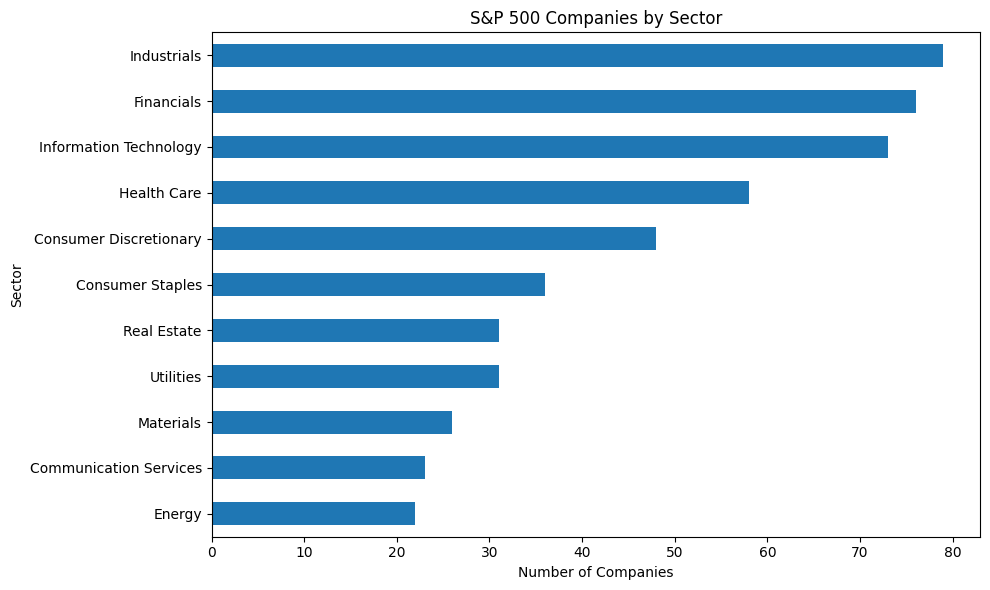

In [47]:
sector_counts = sp500["GICS Sector"].value_counts()
sector_counts.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("S&P 500 Companies by Sector")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

### Observation

Industrials, Financials, and Information Technology have the highest number of companies in the S&P 500 by count.

However, this does not mean they have the highest weight in the index. The S&P 500 is market-cap weighted, so larger companies have more influence than smaller companies.

## Step 7: Sub-Industry Distribution

After looking at broad sectors, I analyzed the GICS sub-industries to get a more detailed view of the types of businesses inside the S&P 500.

This helps show whether the index is concentrated in specific business types, not just broad sectors.

In [48]:
sp500['GICS Sub-Industry'].value_counts()

GICS Sub-Industry
Health Care Equipment                           16
Application Software                            15
Electric Utilities                              15
Semiconductors                                  14
Industrial Machinery & Supplies & Components    14
                                                ..
Health Care Technology                           1
Food Distributors                                1
Passenger Ground Transportation                  1
Timber REITs                                     1
Homefurnishing Retail                            1
Name: count, Length: 127, dtype: int64

### Observation

The sub-industry count gives a more detailed view of what types of companies are in the S&P 500.

This is still based on company count, not index weight. A sub-industry with fewer companies may still represent a large part of the index if those companies have very large market capitalizations.

## Step 8: Visualize the Top Sub-Industries

The S&P 500 contains many different sub-industries, so I focused on the top 15 by company count.

This makes the chart easier to read while still showing which business types appear most often in the index.

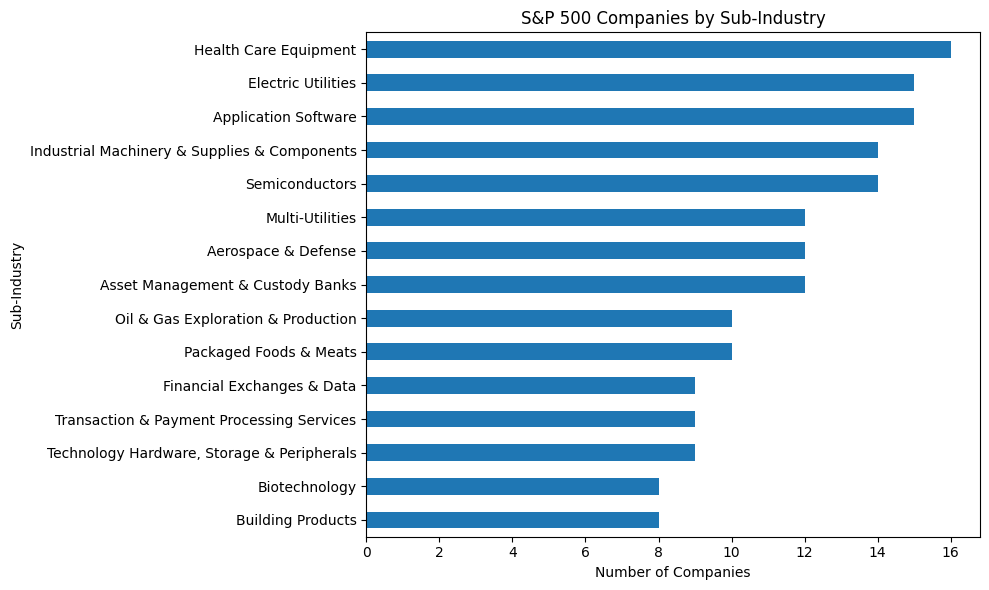

In [49]:
sub_industry_counts = sp500["GICS Sub-Industry"].value_counts()
top_15_sub_industries = sub_industry_counts.head(15)

top_15_sub_industries.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("S&P 500 Companies by Sub-Industry")
plt.xlabel("Number of Companies")
plt.ylabel("Sub-Industry")
plt.tight_layout()
plt.show()

### Note

There are many different sub-industries in the S&P 500, so I selected only the top 15 by company count. This makes the result easier to read and visualize.

## Step 9: Company Age Analysis

After calculating company age, I analyzed the age distribution of companies in the S&P 500.

This helps show whether the index is mostly made up of older established companies, newer companies, or a mix of both.

In [50]:
sp500['Company age'].describe()

count    503.000000
mean      68.741551
std       48.926410
min        1.000000
25%       31.000000
50%       55.000000
75%      103.000000
max      242.000000
Name: Company age, dtype: float64

In [51]:
sp500 = sp500.sort_values(by='Company age', ascending=True)
sp500[['Symbol', 'Security', 'Founded', 'Company age']].head()

,Symbol,Security,Founded,Company age
359,PSKY,Paramount Skydance Corporation,2025 (Paramount Pictures 1912),1.0
386,Q,Qnity Electronics,2025,1.0
215,GEV,GE Vernova,2024,2.0
445,TKO,TKO Group Holdings,2023,3.0
467,VLTO,Veralto,2023,3.0


### Observation

The company age analysis shows the range of company ages inside the S&P 500. Some companies are over 100 years old, while others are much newer.

This shows that the S&P 500 includes both long-established businesses and newer companies that have grown large enough to be included in the index.

## Step 10: Visualize Company Age Distribution

After calculating company age, I created a histogram to see how company ages are distributed across the S&P 500.

This helps show whether the index is mostly made up of older established companies, newer companies, or a mix of both.

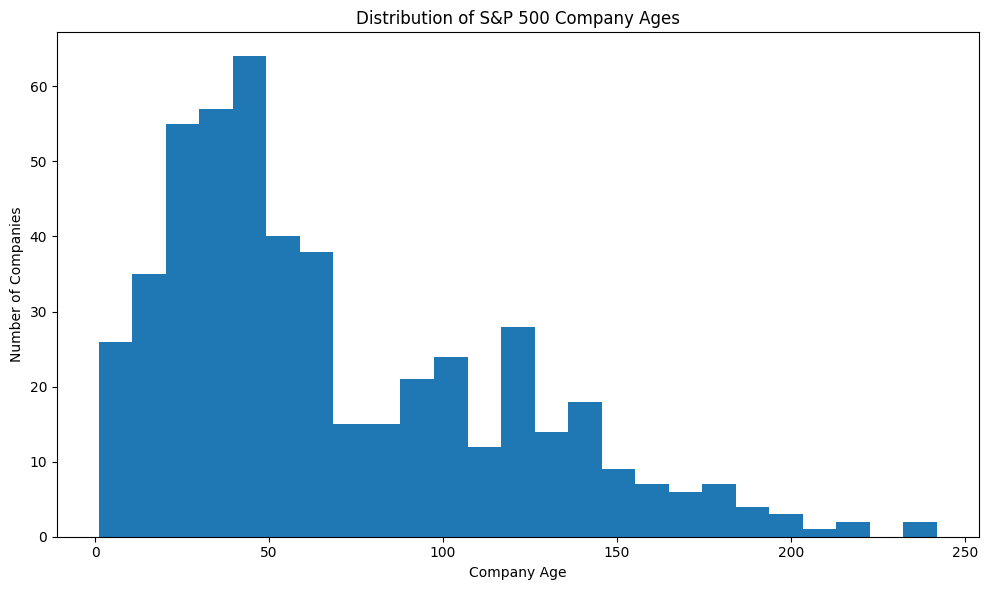

In [52]:
ages = sp500["Company age"]

plt.figure(figsize=(10, 6))
plt.hist(ages, bins=25)

plt.title("Distribution of S&P 500 Company Ages")
plt.xlabel("Company Age")
plt.ylabel("Number of Companies")

plt.tight_layout()
plt.show()

### Observation

The histogram shows that the S&P 500 includes companies with a wide range of ages.

There appears to be an inclination toward companies around the 30 to 50 year age range. This suggests that many companies in the index are established businesses, but not necessarily extremely old companies.

The index also includes much older companies that are over 100 years old, as well as newer companies that became large enough to be included.

## Step 11: Test Financial Data Collection

The earlier sections analyzed the S&P 500 company list using basic company information such as sector, sub-industry, and company age.

The next part of the project collects financial data. I will start by testing one company first to understand the yfinance syntax and check which financial fields are available.

In [53]:
import yfinance as yf

In [54]:
apple = yf.Ticker("AAPL")
apple_info = apple.info
apple_info.get("marketCap")

4213141667840

In [55]:
apple_info.get("priceToBook")

47.825108

In [56]:
apple_info.get("trailingPE")

34.686214

In [57]:
apple_info.get("forwardPE")

29.970861

In [58]:
apple_info.get("dividendYield")

0.38

### Observation

The yfinance test successfully returned Apple’s market capitalization and several valuation metrics.

This confirms that yfinance can provide financial data that may help estimate company size, valuation, and income characteristics for the S&P 500 analysis.

## Step 12: Create a Financial Data Table for One Company

After testing individual yfinance fields, I organized the selected financial values into a small table.

This makes the data easier to inspect and prepares the project for collecting the same fields from multiple companies.

In [59]:
apple_record = {
    "Symbol": "AAPL",
    "Market Cap": apple_info.get("marketCap"),
    "Price to Book": apple_info.get("priceToBook"),
    "Trailing P/E": apple_info.get("trailingPE"),
    "Forward P/E": apple_info.get("forwardPE"),
    "Dividend Yield": apple_info.get("dividendYield")
}


In [60]:
apple_financials = pd.DataFrame([apple_record])
apple_financials.head()

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,AAPL,4213141667840,47.825108,34.686214,29.970861,0.38


### Observation

The selected yfinance fields were organized into a one-row DataFrame for Apple.

This structure can be reused later to collect the same financial data for multiple S&P 500 companies.

## Step 13: Test Financial Data Collection with Multiple Companies

After testing yfinance with one company, I repeated the process with a small list of companies.

This helps confirm that the same financial fields can be collected consistently across multiple tickers before scaling the process to the full S&P 500.

In [61]:
test_symbols = ["AAPL", "MSFT", "NVDA"]

financial_records = []

for symbol in test_symbols:
    ticker = yf.Ticker(symbol)
    info = ticker.info

    record = {
        "Symbol": symbol,
        "Market Cap": info.get("marketCap"),
        "Price to Book": info.get("priceToBook"),
        "Trailing P/E": info.get("trailingPE"),
        "Forward P/E": info.get("forwardPE"),
        "Dividend Yield": info.get("dividendYield")
    }

    financial_records.append(record)

test_financials = pd.DataFrame(financial_records)

test_financials

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,AAPL,4213141667840,47.825108,34.686214,29.970861,0.38
1,MSFT,3069132144640,7.852513,24.622168,21.278580,0.88
2,NVDA,5005007388672,31.817831,42.111454,18.322067,0.02


### Observation

The loop successfully collected financial data for multiple companies and stored the results in a pandas DataFrame.

This confirms that the project can repeat the yfinance collection process across a list of tickers. The next step is to prepare the S&P 500 ticker symbols so they can be used with yfinance.

## Step 14: Prepare Tickers for yfinance

The original S&P 500 dataset includes a `Symbol` column. Some tickers use periods, but yfinance often uses dashes instead.

I created a new column called `YF Symbol` so the project can keep the original ticker symbols while also having a version formatted for yfinance.

In [62]:
sp500["YF Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)
sp500[["Symbol", "YF Symbol", "Security"]].head(30)

,Symbol,YF Symbol,Security
359,PSKY,PSKY,Paramount Skydance Corporation
386,Q,Q,Qnity Electronics
215,GEV,GEV,GE Vernova
445,TKO,TKO,TKO Group Holdings
467,VLTO,VLTO,Veralto
417,SOLV,SOLV,Solventum
271,KVUE,KVUE,Kenvue
483,WBD,WBD,Warner Bros. Discovery
134,CTRA,CTRA,Coterra
87,CARR,CARR,Carrier Global


In [63]:
sp500[sp500["Symbol"] != sp500["YF Symbol"]][["Symbol", "YF Symbol", "Security"]]

,Symbol,YF Symbol,Security
76,BF.B,BF-B,Brown–Forman
61,BRK.B,BRK-B,Berkshire Hathaway


### Observation

A new column called `YF Symbol` was created for yfinance-compatible ticker symbols.

Most tickers stayed the same because they do not contain periods. However, this step is important because some S&P 500 tickers use periods in the original `Symbol` column, while yfinance often expects dashes instead.

Keeping both columns is useful because `Symbol` preserves the original ticker from the S&P 500 dataset, while `YF Symbol` can be used later to collect financial data with yfinance.

## Step 15: Create the S&P 500 Symbol List

After creating the `YF Symbol` column, I converted it into a Python list.

This list will be used in the financial data collection loop so yfinance can collect data for each company one ticker at a time.

In [64]:
sp500_symbols = sp500["YF Symbol"].tolist()

sp500_symbols[:10]

['PSKY', 'Q', 'GEV', 'TKO', 'VLTO', 'SOLV', 'KVUE', 'WBD', 'CTRA', 'CARR']

In [65]:
len(sp500_symbols)

503

### Observation

The `YF Symbol` column was converted into a Python list for financial data collection.

The number of symbols in the list matches the number of rows in the S&P 500 dataset, which means each row has a ticker symbol ready for the yfinance loop.

## Step 16: Collect Financial Data with yfinance

Using the S&P 500 symbol list, I collected financial data for each company with yfinance.

The goal of this step is to collect valuation-related fields such as market capitalization, price-to-book ratio, P/E ratios, and dividend yield. These fields will be used later to estimate index weights and compare valuation across companies and sectors.

Because financial data can sometimes be missing or unavailable, this step should be checked carefully before using the data for analysis.

In [66]:
financial_records = []
#company_number = 0
for symbol in sp500_symbols:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    
    record = {
        "Symbol": symbol,
        "Market Cap": info.get("marketCap"),
        "Price to Book": info.get("priceToBook"),
        "Trailing P/E": info.get("trailingPE"),
        "Forward P/E": info.get("forwardPE"),
        "Dividend Yield": info.get("dividendYield")
    }

    financial_records.append(record)
    #company_number += 1
    #print(company_number)
yf_financials = pd.DataFrame(financial_records)

yf_financials.head(10)

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,PSKY,12260541440,1.053062,365.166700,12.610362,1.88
1,Q,31331428352,4.413467,45.284850,34.056520,0.22
2,GEV,298662133760,21.452356,32.526340,45.388092,0.14
3,TKO,14229613568,3.949521,83.986725,41.565750,1.67
4,VLTO,21499760640,7.154884,22.561855,18.855408,0.59
5,SOLV,12188750848,2.414095,8.599143,10.072185,NaN
6,KVUE,33867321344,3.139907,23.210526,14.712751,4.78
7,WBD,68444880896,1.885314,94.155174,-1560.285800,NaN
8,CTRA,24960051200,1.683569,14.674107,11.114642,2.47
9,CARR,56687112192,4.218171,45.500000,21.354084,1.50


The yfinance loop originally printed progress for each ticker while collecting data. This helped confirm the loop was running, but the long output was removed from the final notebook for readability.

### Observation

The financial data collection loop created a DataFrame with valuation-related data for S&P 500 companies.

This dataset includes market capitalization and valuation metrics that can be used in later analysis. Since yfinance data may have missing values for some companies, the next step is to inspect missing data before calculating weights or valuation ratios.

## Step 17: Check Financial Data Quality

After collecting financial data with yfinance, I inspected the new financial dataset before using it for analysis.

This step checks whether the data loaded correctly, how many rows were collected, the data types of each column, and whether important fields have missing values.

This is important because financial data sources may not return every metric for every company.

In [67]:
print(yf_financials.info())

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          503 non-null    str    
 1   Market Cap      503 non-null    int64  
 2   Price to Book   503 non-null    float64
 3   Trailing P/E    476 non-null    float64
 4   Forward P/E     503 non-null    float64
 5   Dividend Yield  408 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 23.7 KB
None


In [68]:
print(yf_financials.describe())

         Market Cap  Price to Book  Trailing P/E  Forward P/E  Dividend Yield
count  5.030000e+02     503.000000    476.000000   503.000000      408.000000
mean   1.426639e+11       6.401309     37.106940    17.042899        2.253627
std    4.825665e+11      81.807342     50.174014    72.229423        1.626037
min    5.649995e+09   -1146.886400      4.239718 -1560.285800        0.020000
25%    2.206101e+10       1.858111     17.368206    12.169553        1.060000
50%    4.199668e+10       3.262400     25.086511    16.967493        1.875000
75%    9.292304e+10       7.678627     35.772400    23.880067        3.072500
max    5.000754e+12    1320.000000    493.285700   157.780350       10.000000


In [69]:
print(yf_financials.isna().sum())

Symbol             0
Market Cap         0
Price to Book      0
Trailing P/E      27
Forward P/E        0
Dividend Yield    95
dtype: int64


In [70]:
print(len(sp500_symbols))

503


In [71]:
missing_percent = yf_financials.isna().mean() * 100

missing_percent

Symbol             0.000000
Market Cap         0.000000
Price to Book      0.000000
Trailing P/E       5.367793
Forward P/E        0.000000
Dividend Yield    18.886680
dtype: float64

In [72]:
missing_market_cap = yf_financials[yf_financials["Market Cap"].isna()]

missing_market_cap

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield


### Review Missing and Unusual Valuation Values

After checking general missing values, I reviewed specific valuation fields more carefully.

Dividend yield, trailing P/E, and forward P/E need extra attention because missing or unusual values may have different meanings. For example, a missing dividend yield may mean a company does not pay dividends, while a missing trailing P/E may happen when earnings are negative, zero, or unavailable.

In [73]:
missing_trailing_pe = yf_financials[yf_financials["Trailing P/E"].isna()]

missing_trailing_pe

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
13,DOW,27954028544,1.833204,NaN,18.745457,3.43
26,KHC,27397773312,0.657734,NaN,10.816482,7.10
28,HPE,39832162304,1.610342,NaN,11.041108,1.90
45,CRWD,118734512128,26.786245,NaN,75.902560,NaN
47,MRNA,19299684352,2.215542,NaN,-11.142495,NaN
48,LYV,39425728512,144.801380,NaN,78.649895,NaN
54,SATS,36573724672,6.321695,NaN,-85.899430,NaN
58,LYB,23717087232,2.347454,NaN,9.941673,6.17
62,TAP,8030011392,0.798519,NaN,8.543197,4.55
127,ARE,8147097600,0.515362,NaN,-53.125000,9.32


In [74]:
lowest_forward_pe = yf_financials.sort_values("Forward P/E").head(10)

lowest_forward_pe

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
7,WBD,68444880896,1.885314,94.155174,-1560.285800,NaN
54,SATS,36573724672,6.321695,NaN,-85.899430,NaN
127,ARE,8147097600,0.515362,NaN,-53.125000,9.32
47,MRNA,19299684352,2.215542,NaN,-11.142495,NaN
147,CHTR,22122649600,1.176179,4.239718,3.543881,NaN
81,GPN,19030300672,0.714973,15.607223,4.267919,1.44
406,GM,70690553856,1.139866,28.613138,5.582523,0.95
449,TPL,28939593728,19.835089,60.225250,5.740837,0.56
243,EG,14028704768,0.927879,7.178819,5.797852,2.29
299,VTRS,18589978624,1.249315,NaN,5.997415,3.09


In [75]:
highest_forward_pe = yf_financials.sort_values("Forward P/E", ascending=False).head(10)

highest_forward_pe

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
72,TSLA,1502402183168,18.268713,367.000000,157.780350,NaN
185,DOC,13574885376,1.809378,195.250000,144.629620,7.39
94,VTR,42248151040,3.218399,158.000000,95.845240,2.40
209,CPT,10412935168,2.562111,29.353352,82.496605,4.05
48,LYV,39425728512,144.801380,NaN,78.649895,NaN
45,CRWD,118734512128,26.786245,NaN,75.902560,NaN
276,INTC,557483884544,4.847054,NaN,73.152240,NaN
73,PLTR,320808321024,43.321465,152.068190,66.514244,NaN
152,CIEN,80983121920,29.012209,362.487300,66.196860,NaN
261,WELL,152068079616,3.561426,103.567314,65.212980,1.38


In [76]:
missing_forward_pe = yf_financials[yf_financials["Forward P/E"].isna()]

missing_forward_pe

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield


### Observation

While checking the financial data, I noticed that some valuation fields had missing or unusual values. Dividend yield had missing values, which likely happens because many companies do not pay dividends, although some values may also be unavailable from yfinance.

I also noticed missing trailing P/E values and unusual forward P/E values. After looking into why this can happen, I found that P/E ratios can become missing, negative, or misleading when a company has negative earnings, zero earnings, unusual earnings estimates, or unavailable data.

At this stage, I decided not to manually change or force-fill these values. Keeping the data as collected helps preserve the original financial dataset. However, I am noting this as a data-quality issue and may return to it later before using P/E ratios for deeper valuation analysis.

## Step 18: Merge Company and Financial Data

The project currently has two datasets: one with S&P 500 company information and one with financial data collected from yfinance.

I merged these datasets so each company has its sector, sub-industry, company age, market capitalization, valuation ratios, and dividend yield in one table.

This combined dataset will be used for the main valuation and ownership analysis.

In [77]:
yf_financials_for_merge = yf_financials.rename(columns={"Symbol": "YF Symbol"})

In [78]:
sp500_combined = sp500.merge(
    yf_financials_for_merge,
    on="YF Symbol",
    how="left"
)

sp500_combined.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,Founded year,Company age,YF Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,PSKY,Paramount Skydance Corporation,Communication Services,Movies & Entertainment,"Los Angeles, California",1994-09-30,2041610,2025 (Paramount Pictures 1912),2025.0,1.0,PSKY,12260541440,1.053062,365.166700,12.610362,1.88
1,Q,Qnity Electronics,Information Technology,Semiconductor Materials & Equipment,"Wilmington, Delaware",2025-11-03,2058873,2025,2025.0,1.0,Q,31331428352,4.413467,45.284850,34.056520,0.22
2,GEV,GE Vernova,Industrials,Heavy Electrical Equipment,"Cambridge, Massachusetts",2024-04-02,1996810,2024,2024.0,2.0,GEV,298662133760,21.452356,32.526340,45.388092,0.14
3,TKO,TKO Group Holdings,Communication Services,Movies & Entertainment,"New York City, New York",2025-03-24,1973266,2023,2023.0,3.0,TKO,14229613568,3.949521,83.986725,41.565750,1.67
4,VLTO,Veralto,Industrials,Environmental & Facilities Services,"Waltham, Massachusetts",2023-10-02,1967680,2023,2023.0,3.0,VLTO,21499760640,7.154884,22.561855,18.855408,0.59


In [79]:
sp500_combined.shape

(503, 16)

In [80]:
sp500_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Symbol                 503 non-null    str           
 1   Security               503 non-null    str           
 2   GICS Sector            503 non-null    str           
 3   GICS Sub-Industry      503 non-null    str           
 4   Headquarters Location  503 non-null    str           
 5   Date added             503 non-null    datetime64[us]
 6   CIK                    503 non-null    int64         
 7   Founded                503 non-null    str           
 8   Founded year           503 non-null    float64       
 9   Company age            503 non-null    float64       
 10  YF Symbol              503 non-null    str           
 11  Market Cap             503 non-null    int64         
 12  Price to Book          503 non-null    float64       
 13  Trailing P/E    

In [81]:
sp500_combined[
    [
        "Symbol",
        "YF Symbol",
        "Security",
        "GICS Sector",
        "Market Cap",
        "Price to Book",
        "Trailing P/E",
        "Forward P/E",
        "Dividend Yield"
    ]
].head(10)

,Symbol,YF Symbol,Security,GICS Sector,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,PSKY,PSKY,Paramount Skydance Corporation,Communication Services,12260541440,1.053062,365.166700,12.610362,1.88
1,Q,Q,Qnity Electronics,Information Technology,31331428352,4.413467,45.284850,34.056520,0.22
2,GEV,GEV,GE Vernova,Industrials,298662133760,21.452356,32.526340,45.388092,0.14
3,TKO,TKO,TKO Group Holdings,Communication Services,14229613568,3.949521,83.986725,41.565750,1.67
4,VLTO,VLTO,Veralto,Industrials,21499760640,7.154884,22.561855,18.855408,0.59
5,SOLV,SOLV,Solventum,Health Care,12188750848,2.414095,8.599143,10.072185,NaN
6,KVUE,KVUE,Kenvue,Consumer Staples,33867321344,3.139907,23.210526,14.712751,4.78
7,WBD,WBD,Warner Bros. Discovery,Communication Services,68444880896,1.885314,94.155174,-1560.285800,NaN
8,CTRA,CTRA,Coterra,Energy,24960051200,1.683569,14.674107,11.114642,2.47
9,CARR,CARR,Carrier Global,Industrials,56687112192,4.218171,45.500000,21.354084,1.50


### Troubleshooting Note

The merge failed at first because the financial dataset used the column name `Symbol`, while the S&P 500 dataset used `YF Symbol` for the yfinance-compatible ticker.

To fix this, I renamed the ticker column in the financial dataset to `YF Symbol` before merging. This allowed both datasets to join using the same ticker column.

### Observation

The S&P 500 company dataset was merged with the yfinance financial dataset using the `YF Symbol` column.

The first merge attempt failed because the financial dataset used the column name `Symbol`, while the S&P 500 dataset used `YF Symbol` for the yfinance-compatible ticker. I fixed this by renaming the financial dataset’s ticker column to `YF Symbol` before merging.

The combined dataset now includes both company information and financial metrics in one table. This makes it possible to analyze S&P 500 companies by sector, sub-industry, company age, market capitalization, valuation ratios, and dividend yield.

## Step 19: Estimate Company Weights

After merging company information with financial data, I estimated each company’s weight in the S&P 500 using market capitalization.

This is an estimate, not the official S&P 500 weight. The official index uses float-adjusted market capitalization, while this project uses regular market capitalization from yfinance.

Even though it is an estimate, this step helps show which companies have the largest influence in the index and how much of every $100 invested may go toward each company.

In [82]:
total_market_cap = sp500_combined["Market Cap"].sum()
total_market_cap

np.int64(71759951770112)

In [83]:
sp500_combined['Estimated Weight'] = sp500_combined['Market Cap'] / total_market_cap
sp500_combined['Dollars per $100'] = sp500_combined['Estimated Weight'] * 100
sp500_combined[['Symbol', 'Security', 'Market Cap', 'Estimated Weight', 'Dollars per $100']].head(10)

,Symbol,Security,Market Cap,Estimated Weight,Dollars per $100
0,PSKY,Paramount Skydance Corporation,12260541440,0.000171,0.017085
1,Q,Qnity Electronics,31331428352,0.000437,0.043661
2,GEV,GE Vernova,298662133760,0.004162,0.416196
3,TKO,TKO Group Holdings,14229613568,0.000198,0.019829
4,VLTO,Veralto,21499760640,0.000300,0.029961
5,SOLV,Solventum,12188750848,0.000170,0.016985
6,KVUE,Kenvue,33867321344,0.000472,0.047195
7,WBD,Warner Bros. Discovery,68444880896,0.000954,0.095380
8,CTRA,Coterra,24960051200,0.000348,0.034783
9,CARR,Carrier Global,56687112192,0.000790,0.078995


In [84]:
sp500_combined.sort_values("Estimated Weight", ascending=False).head(10)[['Symbol', 'Security', 'Market Cap', 'Estimated Weight', 'Dollars per $100']]


,Symbol,Security,Market Cap,Estimated Weight,Dollars per $100
140,NVDA,Nvidia,5000753840128,0.069687,6.968725
93,GOOGL,Alphabet Inc. (Class A),4804742479872,0.066956,6.695577
96,GOOG,Alphabet Inc. (Class C),4766215700480,0.066419,6.641888
230,AAPL,Apple Inc.,4215711727616,0.058747,5.874742
242,MSFT,Microsoft,3071648202752,0.042804,4.280449
137,AMZN,Amazon,2980687380480,0.041537,4.153692
301,AVGO,Broadcom,1995804770304,0.027812,2.781224
67,META,Meta Platforms,1558211067904,0.021714,2.171422
72,TSLA,"Tesla, Inc.",1502402183168,0.020936,2.093650
296,WMT,Walmart,1036467896320,0.014444,1.444354


### Observation

The estimated weight column shows which companies have the largest influence in the S&P 500 based on market capitalization.

The `Dollars per $100` column makes the weights easier to understand by showing approximately how much of every $100 invested in the S&P 500 would go toward each company.

These weights are estimates because the official S&P 500 uses float-adjusted market capitalization, while this project uses regular market capitalization from yfinance.

## Step 20: Check Estimated Weight Columns

After calculating estimated company weights, I checked the updated dataset to make sure the new columns were created correctly.

This step verifies that the estimated weight columns exist, have numeric data types, and do not contain missing values before using them for further analysis.

In [85]:
sp500_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Symbol                 503 non-null    str           
 1   Security               503 non-null    str           
 2   GICS Sector            503 non-null    str           
 3   GICS Sub-Industry      503 non-null    str           
 4   Headquarters Location  503 non-null    str           
 5   Date added             503 non-null    datetime64[us]
 6   CIK                    503 non-null    int64         
 7   Founded                503 non-null    str           
 8   Founded year           503 non-null    float64       
 9   Company age            503 non-null    float64       
 10  YF Symbol              503 non-null    str           
 11  Market Cap             503 non-null    int64         
 12  Price to Book          503 non-null    float64       
 13  Trailing P/E    

In [86]:
sp500_combined[["Estimated Weight", "Dollars per $100"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Estimated Weight  503 non-null    float64
 1   Dollars per $100  503 non-null    float64
dtypes: float64(2)
memory usage: 8.0 KB


In [87]:
sp500_combined[["Estimated Weight", "Dollars per $100"]].isna().sum()

Estimated Weight    0
Dollars per $100    0
dtype: int64

In [88]:
sp500_combined[["Estimated Weight", "Dollars per $100"]].describe()

,Estimated Weight,Dollars per $100
count,503.000000,503.000000
mean,0.001988,0.198807
std,0.006725,0.672473
min,0.000079,0.007873
25%,0.000307,0.030743
50%,0.000585,0.058524
75%,0.001295,0.129492
max,0.069687,6.968725


In [89]:
sp500_combined["Estimated Weight"].sum()

np.float64(1.0)

In [90]:
sp500_combined["Dollars per $100"].sum()

np.float64(100.0)

### Observation

The estimated weight columns were checked before further analysis.

Both `Estimated Weight` and `Dollars per $100` are numeric columns, which means they can be used for sorting, grouping, and calculations.

The estimated weights add up to approximately 1, and the dollars-per-$100 column adds up to approximately 100. This confirms that the weight calculation worked correctly.

## Step 21: Analyze Largest Estimated Holdings

After estimating company weights, I analyzed the largest companies in the dataset.

This step helps show how concentrated the S&P 500 is in its biggest holdings. The S&P 500 is not equally weighted, so larger companies represent a much bigger share of the index than smaller companies.

I used the `Dollars per $100` column to make the result easier to understand.

In [91]:
top_10_holdings = sp500_combined.sort_values("Estimated Weight", ascending=False).head(10)

top_10_holdings[['Symbol', 'Security', 'GICS Sector', 'Market Cap', 'Estimated Weight', 'Dollars per $100']]

,Symbol,Security,GICS Sector,Market Cap,Estimated Weight,Dollars per $100
140,NVDA,Nvidia,Information Technology,5000753840128,0.069687,6.968725
93,GOOGL,Alphabet Inc. (Class A),Communication Services,4804742479872,0.066956,6.695577
96,GOOG,Alphabet Inc. (Class C),Communication Services,4766215700480,0.066419,6.641888
230,AAPL,Apple Inc.,Information Technology,4215711727616,0.058747,5.874742
242,MSFT,Microsoft,Information Technology,3071648202752,0.042804,4.280449
137,AMZN,Amazon,Consumer Discretionary,2980687380480,0.041537,4.153692
301,AVGO,Broadcom,Information Technology,1995804770304,0.027812,2.781224
67,META,Meta Platforms,Communication Services,1558211067904,0.021714,2.171422
72,TSLA,"Tesla, Inc.",Consumer Discretionary,1502402183168,0.020936,2.093650
296,WMT,Walmart,Consumer Staples,1036467896320,0.014444,1.444354


In [92]:
top_10_weight = top_10_holdings["Estimated Weight"].sum()
top_10_dollars = top_10_holdings["Dollars per $100"].sum()

print(f"Top 10 estimated weight: {top_10_weight:.2%}")
print(f"Top 10 dollars per $100: ${top_10_dollars:.2f}")

Top 10 estimated weight: 43.11%
Top 10 dollars per $100: $43.11


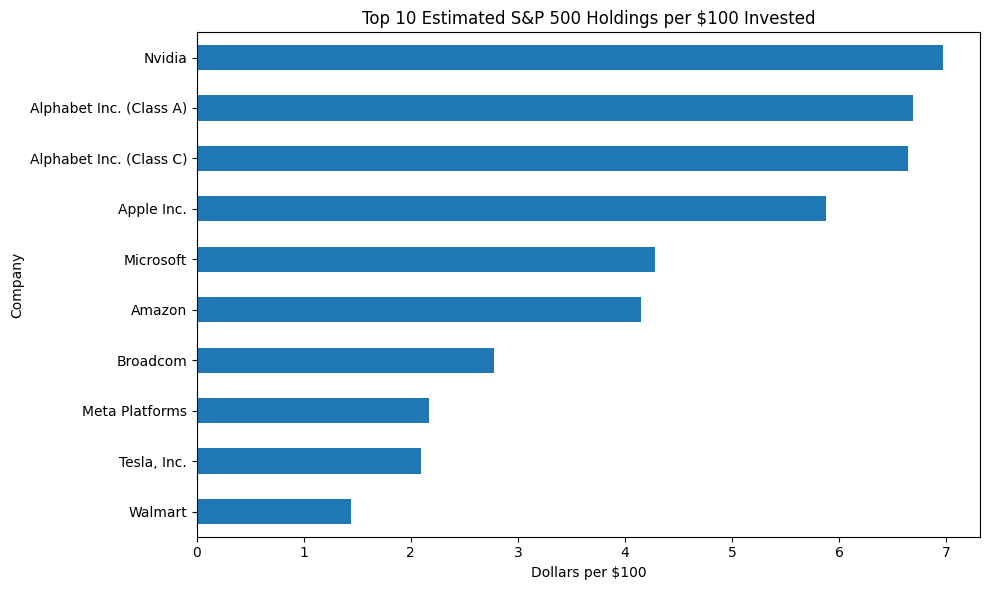

In [93]:
top_10_holdings.sort_values("Dollars per $100").plot(
    kind="barh",
    x="Security",
    y="Dollars per $100",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 Estimated S&P 500 Holdings per $100 Invested")
plt.xlabel("Dollars per $100")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

### Visualizing Estimated Holding Concentration

To better understand concentration, I created multiple charts.

The first chart compares the top 10 companies against the rest of the S&P 500. The second chart shows how the top 10 companies are divided among themselves. 

These charts help show that the S&P 500 is broad, but not equally weighted.

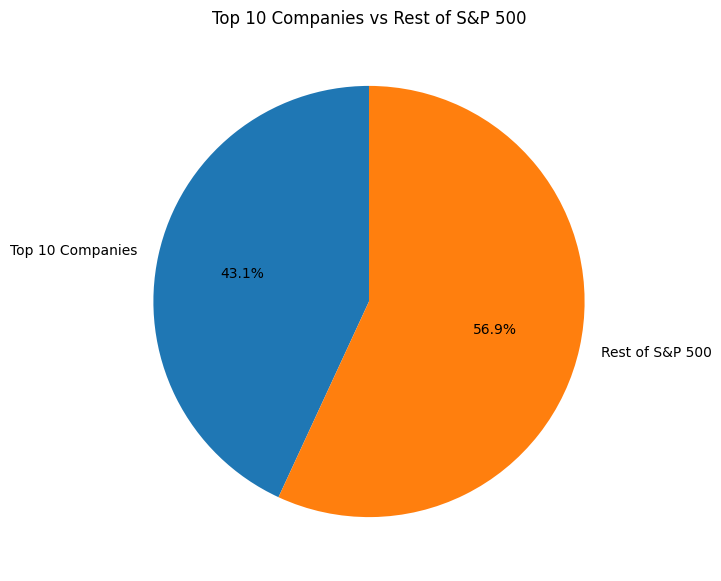

In [94]:
top_10_holdings = sp500_combined.sort_values("Estimated Weight", ascending=False).head(10)

top_10_total = top_10_holdings["Dollars per $100"].sum()
rest_total = 100 - top_10_total

top_10_vs_rest = pd.Series(
    [top_10_total, rest_total],
    index=["Top 10 Companies", "Rest of S&P 500"]
)

plt.figure(figsize=(7, 7))
plt.pie(
    top_10_vs_rest,
    labels=top_10_vs_rest.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Companies vs Rest of S&P 500")
plt.show()

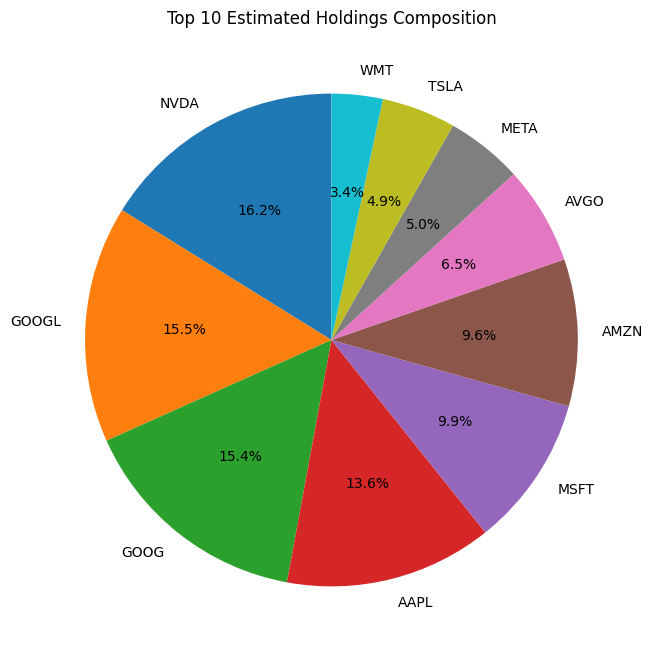

In [95]:
plt.figure(figsize=(8, 8))
plt.pie(
    top_10_holdings["Dollars per $100"],
    labels=top_10_holdings["Symbol"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Estimated Holdings Composition")
plt.show()

### Chart Decision

I chose to focus on pie charts for the top 10 companies because they are easier to interpret for this stage of the project.

A cumulative concentration chart could be useful later, but I am leaving it out for now because I want the project visuals to be clear and easy to explain.

### Observation

The estimated holding analysis shows that the S&P 500 is weighted heavily toward its largest companies.

The top 10 companies make up a large part of the estimated index weight, while the rest of the companies share the remaining weight. This shows that the S&P 500 is diversified across many companies, but it is not equally diversified by investment weight.

This is important because buying the S&P 500 does not mean every company receives the same amount of money. Instead, larger companies receive much more weight, so the performance of the biggest companies can have a strong effect on the overall index.

This changed my understanding of the S&P 500. It is still diversified, but it is more concentrated in the largest companies than I originally expected.

## Step 22: Estimate Sector Weights by Market Cap

After analyzing the largest individual companies, I analyzed the S&P 500 by sector using estimated market-cap weights.

Earlier in the project, I counted how many companies belonged to each sector. However, company count does not show how much of the index each sector represents by investment weight.

This step estimates how much of every $100 invested in the S&P 500 goes toward each GICS sector.

In [96]:
sector_weights = (
    sp500_combined
    .groupby("GICS Sector")[["Market Cap", "Estimated Weight", "Dollars per $100"]]
    .sum()
    .sort_values("Dollars per $100", ascending=False)
)

sector_weights

,Market Cap,Estimated Weight,Dollars per $100
GICS Sector,,,
Information Technology,23103487563776,0.321955,32.195517
Communication Services,12768397987840,0.177932,17.793209
Financials,8098423286784,0.112854,11.285436
Consumer Discretionary,7097496271360,0.098906,9.890609
Industrials,5626718735360,0.078410,7.841029
Health Care,5395836646400,0.075193,7.519287
Consumer Staples,3630911598592,0.050598,5.059802
Energy,2119789565952,0.029540,2.954001
Utilities,1449459286016,0.020199,2.019872


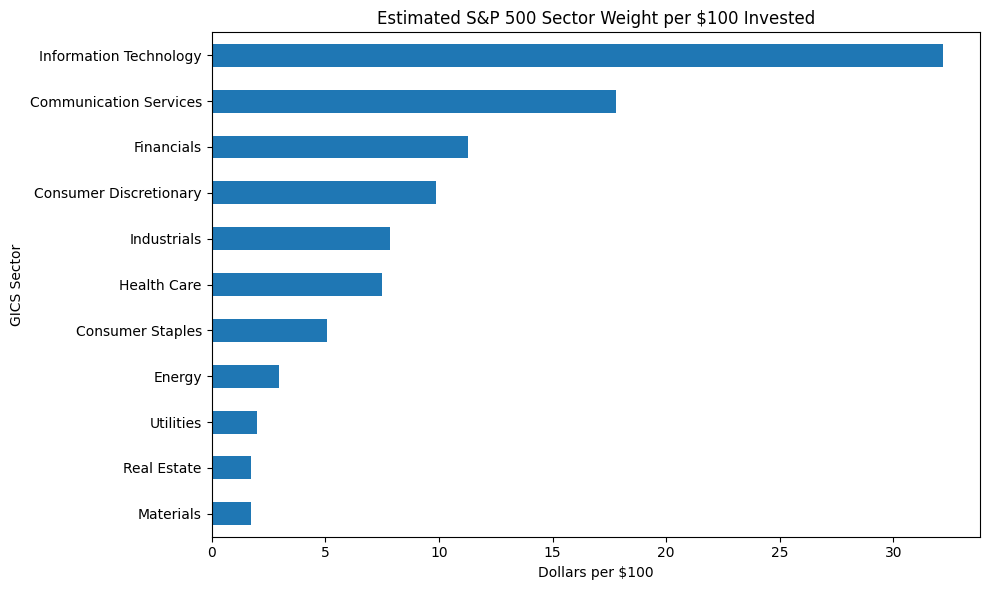

In [97]:
sector_weights.sort_values("Dollars per $100").plot(
    kind="barh",
    y="Dollars per $100",
    figsize=(10, 6),
    legend=False
)

plt.title("Estimated S&P 500 Sector Weight per $100 Invested")
plt.xlabel("Dollars per $100")
plt.ylabel("GICS Sector")
plt.tight_layout()
plt.show()

In [98]:
top_7_sectors = sector_weights["Dollars per $100"].head(7)

other_sectors = sector_weights["Dollars per $100"].iloc[7:].sum()

top_7_plus_other = pd.concat([
    top_7_sectors,
    pd.Series({"Other": other_sectors})
])

top_7_plus_other

Information Technology    32.195517
Communication Services    17.793209
Financials                11.285436
Consumer Discretionary     9.890609
Industrials                7.841029
Health Care                7.519287
Consumer Staples           5.059802
Other                      8.415111
dtype: float64

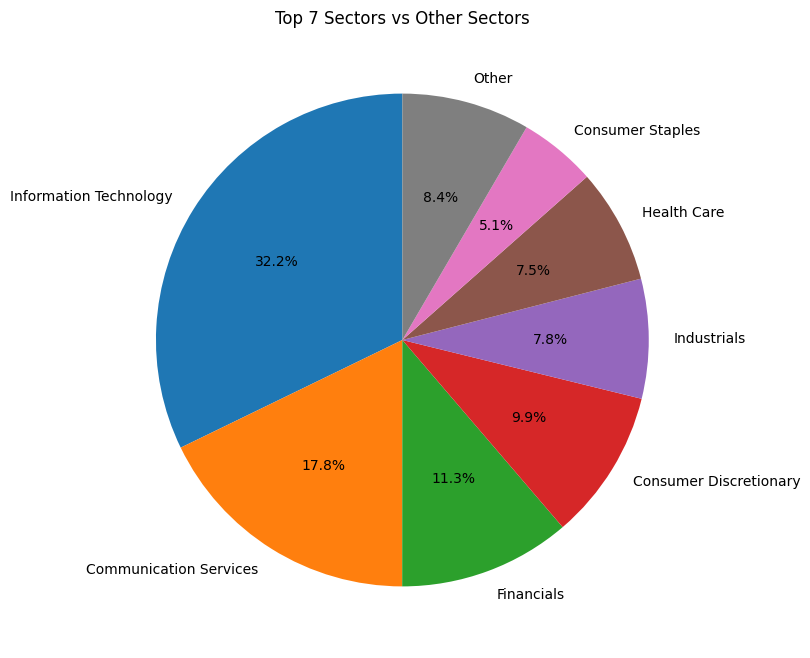

In [99]:
plt.figure(figsize=(8, 8))

plt.pie(
    top_7_plus_other,
    labels=top_7_plus_other.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 7 Sectors vs Other Sectors")
plt.show()

### Top 7 Sectors vs Other

To keep the circle chart readable, I grouped the smaller sectors into an `Other` category. This helps focus the chart on the sectors with the largest estimated weights while still accounting for the full S&P 500.

### Observation

The sector weight analysis shows that the S&P 500 is not evenly divided across sectors.

Earlier in the project, I looked at sector distribution by company count. This step is different because it estimates sector exposure by market capitalization. This is more useful for understanding what an investor is actually buying because the S&P 500 is weighted more heavily toward larger companies.

The results show that some sectors represent a much larger share of the estimated index weight than others. This means that even though the S&P 500 includes many sectors, the investment exposure is still concentrated in the largest sectors.

I chose to visualize the top 7 sectors and group the remaining sectors into `Other` because too many small slices made the circle chart harder to read. This kept the visualization clear while still showing the main sector concentration.

Overall, this step shows that buying the S&P 500 gives broad sector exposure, but it does not mean each sector receives an equal share of the investment.

## Step 23: Compare Sector Count and Sector Weight

After analyzing sector distribution by company count and by estimated market-cap weight, I compared both views side by side.

This helps show the difference between the number of companies in a sector and the amount of investment weight that sector represents in the S&P 500.

In [100]:
sector_count_weight_comparison = pd.DataFrame({
    "Company Count": sector_counts,
    "Dollars per $100": sector_weights["Dollars per $100"],
    "Estimated Weight": sector_weights["Estimated Weight"]
})

sector_count_weight_comparison = sector_count_weight_comparison.sort_values(
    "Dollars per $100",
    ascending=False
)

sector_count_weight_comparison

,Company Count,Dollars per $100,Estimated Weight
GICS Sector,,,
Information Technology,73,32.195517,0.321955
Communication Services,23,17.793209,0.177932
Financials,76,11.285436,0.112854
Consumer Discretionary,48,9.890609,0.098906
Industrials,79,7.841029,0.078410
Health Care,58,7.519287,0.075193
Consumer Staples,36,5.059802,0.050598
Energy,22,2.954001,0.029540
Utilities,31,2.019872,0.020199


In [101]:
sector_count_weight_comparison["Estimated Weight %"] = (
    sector_count_weight_comparison["Estimated Weight"] * 100
)

sector_count_weight_comparison

,Company Count,Dollars per $100,Estimated Weight,Estimated Weight %
GICS Sector,,,,
Information Technology,73,32.195517,0.321955,32.195517
Communication Services,23,17.793209,0.177932,17.793209
Financials,76,11.285436,0.112854,11.285436
Consumer Discretionary,48,9.890609,0.098906,9.890609
Industrials,79,7.841029,0.078410,7.841029
Health Care,58,7.519287,0.075193,7.519287
Consumer Staples,36,5.059802,0.050598,5.059802
Energy,22,2.954001,0.029540,2.954001
Utilities,31,2.019872,0.020199,2.019872


### Observation

The comparison shows that sector company count and sector investment weight are not the same.

A sector can have many companies but still represent a smaller share of the estimated S&P 500 weight if those companies are smaller. Another sector can have fewer companies but represent a larger share if it contains very large companies.

This reinforces that the S&P 500 is not equally distributed across sectors. Market capitalization has a major effect on where the investment exposure actually goes.

## Step 24: Review Price-to-Book Data

Before estimating book value, I reviewed the `Price to Book` column.

This review checks for missing values, zero values, negative values, and extreme values. Negative price-to-book values are not automatically treated as errors because they may represent companies with negative book equity.

The goal of this step is not to remove values automatically, but to understand the data before using it in the book value calculation.

In [102]:
sp500_combined["Price to Book"].describe()

count     503.000000
mean        6.401309
std        81.807342
min     -1146.886400
25%         1.858111
50%         3.262400
75%         7.678627
max      1320.000000
Name: Price to Book, dtype: float64

In [103]:
sp500_combined["Price to Book"].isna().sum()

np.int64(0)

In [104]:
negative_pb = sp500_combined[sp500_combined["Price to Book"] < 0]

negative_pb[
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book"]
]

,Symbol,Security,GICS Sector,Market Cap,Price to Book
10,OTIS,Otis Worldwide,Industrials,29596018688,-5.575797
22,DELL,Dell Technologies,Information Technology,153301499904,-62.243927
32,ABBV,AbbVie,Health Care,362861592576,-110.891884
56,PM,Philip Morris International,Consumer Staples,265375825920,-26.521807
75,WYNN,Wynn Resorts,Consumer Discretionary,11193768960,-39.933033
106,YUM,Yum! Brands,Consumer Discretionary,43212943360,-5.911549
118,BKNG,Booking Holdings,Consumer Discretionary,131210174464,-15.139025
121,VRSN,Verisign,Information Technology,25122371584,-11.362777
130,CCI,Crown Castle,Real Estate,39290167296,-20.444870
146,TDG,TransDigm Group,Industrials,69842132992,-7.524153


In [105]:
sp500_combined.sort_values("Price to Book")[
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book"]
].head(10)

,Symbol,Security,GICS Sector,Market Cap,Price to Book
335,MTD,Mettler Toledo,Health Care,26961592320,-1146.886400
395,CLX,Clorox,Consumer Staples,10811578368,-161.389900
339,MCD,McDonald's,Consumer Discretionary,201597812736,-112.588320
32,ABBV,AbbVie,Health Care,362861592576,-110.891884
315,ORLY,O’Reilly Automotive,Consumer Discretionary,79292522496,-74.313576
494,MCK,McKesson Corporation,Health Care,90967760896,-70.375244
22,DELL,Dell Technologies,Information Technology,153301499904,-62.243927
365,MAS,Masco,Industrials,14432081920,-59.616665
75,WYNN,Wynn Resorts,Consumer Discretionary,11193768960,-39.933033
183,MO,Altria,Consumer Staples,118370238464,-33.883842


In [106]:
sp500_combined.sort_values("Price to Book", ascending=False)[
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book"]
].head(10)

,Symbol,Security,GICS Sector,Market Cap,Price to Book
500,CL,Colgate-Palmolive,Consumer Staples,70768746496,1320.000000
220,STX,Seagate Technology,Information Technology,174259568640,369.367860
48,LYV,Live Nation Entertainment,Communication Services,39425728512,144.801380
113,FIX,Comfort Systems USA,Industrials,70335496192,108.854810
27,LITE,Lumentum,Information Technology,66284187648,78.295520
256,VRSK,Verisk Analytics,Industrials,22614370304,77.295120
42,APP,AppLovin,Information Technology,156458844160,73.738510
289,MA,Mastercard,Financials,433680646144,56.715970
18,TPR,"Tapestry, Inc.",Consumer Discretionary,30284070912,54.424416
79,FTNT,Fortinet,Information Technology,65698832384,53.865543


In [107]:
sp500_combined[sp500_combined["Symbol"].isin(["MTD", "CL"])][
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book"]
]

,Symbol,Security,GICS Sector,Market Cap,Price to Book
335,MTD,Mettler Toledo,Health Care,26961592320,-1146.8864
500,CL,Colgate-Palmolive,Consumer Staples,70768746496,1320.0000


### Observation on Unusual Price-to-Book Values

While reviewing the `Price to Book` column, I noticed that MTD and CL had unusual values compared to most companies in the dataset.

I did not remove these values automatically because unusual price-to-book ratios are not always data errors. They may reflect companies with very small book equity, negative book equity, large share repurchases, strong intangible value, or accounting values that do not fully represent the market value of the business.

However, I am noting these values because they may strongly affect the estimated book value calculation. If the book value estimate looks distorted later, I may return to these companies and review them separately.

### Observation

The `Price to Book` column was reviewed before using it to estimate book value.

There were no values that I decided to remove automatically. Negative price-to-book values are not treated as automatic errors because they may represent companies with negative book equity. These values can still be important when estimating combined book value.

I also noticed unusual price-to-book values for MTD and CL. These values may not be wrong, but they could strongly affect the estimated book value calculation. They may reflect small book equity, negative book equity, share repurchases, intangible value, or accounting values that do not fully represent the market value of the business.

Because of this, I will keep the price-to-book data as collected for now, but I am noting these unusual values as a limitation. If the book value estimate looks distorted later, I may return to these companies and review them separately.

## Step 25: Estimate Book Value

After reviewing the `Price to Book` column, I estimated each company’s book value using market capitalization and price-to-book ratio.

The formula used is:

`Estimated Book Value = Market Cap / Price to Book`

Negative price-to-book values are not removed automatically because they may represent companies with negative book equity. Since this project is estimating combined book value, those values may still be important.

In [108]:
sp500_combined["Estimated Book Value"] = (
    sp500_combined["Market Cap"] / sp500_combined["Price to Book"]
)

sp500_combined[
    ["Symbol", "Security", "Market Cap", "Price to Book", "Estimated Book Value"]
].head(10)

,Symbol,Security,Market Cap,Price to Book,Estimated Book Value
0,PSKY,Paramount Skydance Corporation,12260541440,1.053062,1.164276e+10
1,Q,Qnity Electronics,31331428352,4.413467,7.099051e+09
2,GEV,GE Vernova,298662133760,21.452356,1.392211e+10
3,TKO,TKO Group Holdings,14229613568,3.949521,3.602871e+09
4,VLTO,Veralto,21499760640,7.154884,3.004907e+09
5,SOLV,Solventum,12188750848,2.414095,5.048993e+09
6,KVUE,Kenvue,33867321344,3.139907,1.078609e+10
7,WBD,Warner Bros. Discovery,68444880896,1.885314,3.630424e+10
8,CTRA,Coterra,24960051200,1.683569,1.482568e+10
9,CARR,Carrier Global,56687112192,4.218171,1.343879e+10


In [109]:
sp500_combined["Estimated Book Value"].describe()

count    5.030000e+02
mean     2.160990e+12
std      4.795511e+13
min     -1.000595e+10
25%      4.023070e+09
50%      1.017791e+10
75%      2.256983e+10
max      1.075543e+15
Name: Estimated Book Value, dtype: float64

In [110]:
sp500_combined["Estimated Book Value"].isna().sum()

np.int64(0)

In [111]:
sp500_combined.sort_values("Estimated Book Value", ascending=False)[
    ["Symbol", "Security", "Market Cap", "Price to Book", "Estimated Book Value"]
].head(10)

,Symbol,Security,Market Cap,Price to Book,Estimated Book Value
491,BRK.B,Berkshire Hathaway,1011786579968,0.000941,1.075543e+15
137,AMZN,Amazon,2980687380480,6.742998,4.420419e+11
93,GOOGL,Alphabet Inc. (Class A),4804742479872,11.544260,4.162019e+11
96,GOOG,Alphabet Inc. (Class C),4766215700480,11.451693,4.162018e+11
242,MSFT,Microsoft,3071648202752,7.858951,3.908471e+11
82,JPM,JPMorgan Chase,843992465408,2.453517,3.439930e+11
95,BAC,Bank of America,380341780480,1.386173,2.743826e+11
85,XOM,ExxonMobil,613224218624,2.383557,2.572727e+11
67,META,Meta Platforms,1558211067904,7.148847,2.179668e+11
103,C,Citigroup,224070270976,1.141378,1.963156e+11


In [112]:
sp500_combined.sort_values("Price to Book")[
    ["Symbol", "Security", "Market Cap", "Price to Book", "Estimated Book Value"]
].head(15)

,Symbol,Security,Market Cap,Price to Book,Estimated Book Value
335,MTD,Mettler Toledo,26961592320,-1146.886400,-2.350851e+07
395,CLX,Clorox,10811578368,-161.389900,-6.699043e+07
339,MCD,McDonald's,201597812736,-112.588320,-1.790575e+09
32,ABBV,AbbVie,362861592576,-110.891884,-3.272211e+09
315,ORLY,O’Reilly Automotive,79292522496,-74.313576,-1.066999e+09
494,MCK,McKesson Corporation,90967760896,-70.375244,-1.292610e+09
22,DELL,Dell Technologies,153301499904,-62.243927,-2.462915e+09
365,MAS,Masco,14432081920,-59.616665,-2.420813e+08
75,WYNN,Wynn Resorts,11193768960,-39.933033,-2.803135e+08
183,MO,Altria,118370238464,-33.883842,-3.493413e+09


In [113]:
tiny_positive_pb = sp500_combined[
    (sp500_combined["Price to Book"] > 0) &
    (sp500_combined["Price to Book"] < 0.1)
]

tiny_positive_pb[
    ["Symbol", "Security", "Market Cap", "Price to Book", "Estimated Book Value"]
]

,Symbol,Security,Market Cap,Price to Book,Estimated Book Value
491,BRK.B,Berkshire Hathaway,1011786579968,0.000941,1.075543e+15


### Outlier Check

After calculating estimated book value, I checked for outliers because the maximum estimated book value appeared unusually large.

Since estimated book value is calculated by dividing market capitalization by price-to-book ratio, very small price-to-book values can create extremely large estimates.

This check helps identify whether the book value estimate is being distorted by one or a few unusual companies.

### Data Decision

After calculating estimated book value, I found that very small positive price-to-book values can create extremely large estimated book values.

Because estimated book value is calculated as `Market Cap / Price to Book`, values close to zero can distort the total book value estimate.

To avoid letting one or two extreme values control the entire result, I will keep the original data unchanged but create a filtered version of the dataset for book value analysis. This filtered version will exclude very small positive price-to-book values.

In [114]:
book_value_data = sp500_combined[~((sp500_combined["Price to Book"] > 0) & (sp500_combined["Price to Book"] < 0.1))].copy()

In [115]:
book_value_data["Estimated Book Value"] = (book_value_data["Market Cap"] / book_value_data["Price to Book"])

In [116]:
book_value_data["Estimated Book Value"].describe()

count    5.020000e+02
mean     2.277873e+10
std      4.890453e+10
min     -1.000595e+10
25%      4.018322e+09
50%      1.017712e+10
75%      2.248450e+10
max      4.420419e+11
Name: Estimated Book Value, dtype: float64

In [117]:
removed_book_value_outliers = sp500_combined[
    (sp500_combined["Price to Book"] > 0) &
    (sp500_combined["Price to Book"] < 0.1)
]

removed_book_value_outliers[
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book", "Estimated Book Value"]
]

,Symbol,Security,GICS Sector,Market Cap,Price to Book,Estimated Book Value
491,BRK.B,Berkshire Hathaway,Financials,1011786579968,0.000941,1.075543e+15


In [118]:
brk_b = yf.Ticker("BRK-B")
brk_b.info.get("priceToBook")

0.00094085565

In [119]:
brk_a = yf.Ticker("BRK-A")
brk_a.info.get("priceToBook")

1.4147831

In [120]:
print("BRK-B Price to Book:", brk_b.info.get("priceToBook"))
print("BRK-A Price to Book:", brk_a.info.get("priceToBook"))

BRK-B Price to Book: 0.00094085565
BRK-A Price to Book: 1.4147831


In [121]:
sp500_combined.loc[sp500_combined["YF Symbol"] == "BRK-B", "Price to Book"] = 1.4087871

In [122]:
sp500_combined["Estimated Book Value"] = (
    sp500_combined["Market Cap"] / sp500_combined["Price to Book"]
)

sp500_combined["Estimated Book Value"].describe()

count    5.030000e+02
mean     2.416127e+10
std      5.786478e+10
min     -1.000595e+10
25%      4.023070e+09
50%      1.017791e+10
75%      2.256983e+10
max      7.181969e+11
Name: Estimated Book Value, dtype: float64

### Berkshire Hathaway Price-to-Book Adjustment

While reviewing estimated book value outliers, I found that Berkshire Hathaway’s BRK-B ticker had an extremely low price-to-book value from yfinance.

BRK-B showed a price-to-book value of about 0.00094, while BRK-A showed a price-to-book value of about 1.41. Since BRK-A and BRK-B are share classes of the same company, the BRK-B value appears to be a data issue.

Instead of removing Berkshire Hathaway from the book-value calculation, I adjusted BRK-B’s price-to-book value using the BRK-A price-to-book value. This keeps Berkshire in the dataset while avoiding an unrealistic estimated book value.

### Observation

After adjusting Berkshire Hathaway’s BRK-B price-to-book value using the BRK-A value, the estimated book value results became much more reasonable.

The dataset now keeps all 503 companies while avoiding the unrealistic book value caused by the incorrect BRK-B price-to-book value. The maximum estimated book value is still large, but it is no longer unrealistically distorted.

This correction is important because Berkshire Hathaway is a major S&P 500 company. Removing it completely would make the book value estimate less complete, while keeping the incorrect BRK-B value would distort the total book value calculation.

This step shows why outlier review is important before using calculated financial metrics.

## Step 26: Compare Total Market Value vs Estimated Book Value

After estimating book value for each company, I compared the total market capitalization of the dataset to the total estimated book value.

This helps show how much the market values the S&P 500 companies compared to their combined book value.

The result can also be used to estimate an aggregate price-to-book ratio for the dataset.

In [123]:
total_market_value = sp500_combined["Market Cap"].sum()
total_estimated_book_value = sp500_combined["Estimated Book Value"].sum()

total_market_value, total_estimated_book_value

(np.int64(71759951770112), np.float64(12153117867632.795))

In [124]:
print(f"Total Market Value: ${total_market_value:,.0f}")
print(f"Total Estimated Book Value: ${total_estimated_book_value:,.0f}")

Total Market Value: $71,759,951,770,112
Total Estimated Book Value: $12,153,117,867,633


In [125]:
aggregate_price_to_book = total_market_value / total_estimated_book_value

aggregate_price_to_book

np.float64(5.904653649515663)

In [126]:
print(f"Estimated Aggregate Price-to-Book Ratio: {aggregate_price_to_book:.2f}")

Estimated Aggregate Price-to-Book Ratio: 5.90


In [127]:
market_vs_book = pd.DataFrame({
    "Metric": ["Total Market Value", "Total Estimated Book Value"],
    "Value": [total_market_value, total_estimated_book_value]
})

market_vs_book

,Metric,Value
0,Total Market Value,7.175995e+13
1,Total Estimated Book Value,1.215312e+13


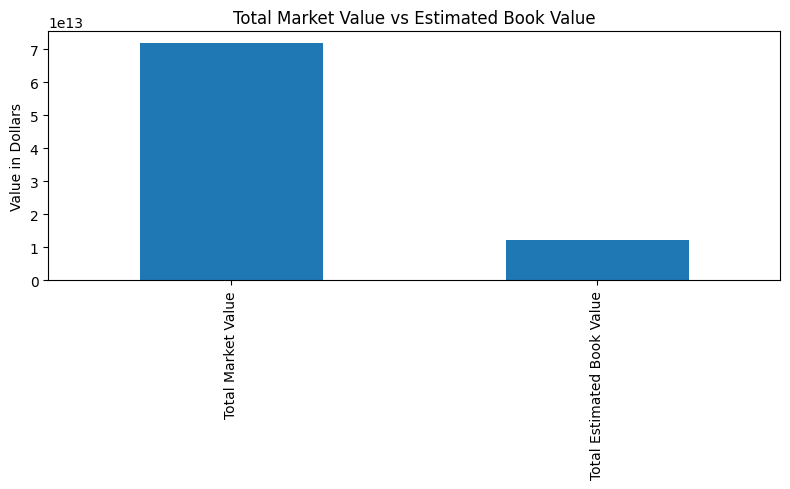

In [128]:
market_vs_book.plot(
    kind="bar",
    x="Metric",
    y="Value",
    figsize=(8, 5),
    legend=False
)

plt.title("Total Market Value vs Estimated Book Value")
plt.ylabel("Value in Dollars")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Limitation

This aggregate price-to-book ratio is an estimate because it depends on yfinance market cap and price-to-book data. Some companies may have unusual book values because of accounting differences, intangible assets, share repurchases, or negative book equity.

### Observation

The total market value was compared to the total estimated book value to calculate an estimated aggregate price-to-book ratio.

This calculation is not the same as taking a simple average of each company’s price-to-book ratio. Instead, it compares the total market capitalization of the companies to their total estimated book value, so larger companies naturally have more influence on the result.

This gives an approximate view of how much the market values the S&P 500 companies compared to their combined accounting book value.

## Step 27: Analyze Aggregate Price-to-Book by Sector

After calculating the total aggregate price-to-book ratio for the full dataset, I analyzed the same idea by GICS sector.

For each sector, I summed the total market capitalization and total estimated book value. Then I calculated the sector aggregate price-to-book ratio.

This method uses the sector as a whole instead of treating every company equally.

In [129]:
negative_pb = sp500_combined[sp500_combined["Price to Book"] < 0]

negative_pb[
    ["Symbol", "Security", "GICS Sector", "Market Cap", "Price to Book", "Estimated Book Value"]
]

,Symbol,Security,GICS Sector,Market Cap,Price to Book,Estimated Book Value
10,OTIS,Otis Worldwide,Industrials,29596018688,-5.575797,-5.307944e+09
22,DELL,Dell Technologies,Information Technology,153301499904,-62.243927,-2.462915e+09
32,ABBV,AbbVie,Health Care,362861592576,-110.891884,-3.272211e+09
56,PM,Philip Morris International,Consumer Staples,265375825920,-26.521807,-1.000595e+10
75,WYNN,Wynn Resorts,Consumer Discretionary,11193768960,-39.933033,-2.803135e+08
106,YUM,Yum! Brands,Consumer Discretionary,43212943360,-5.911549,-7.309919e+09
118,BKNG,Booking Holdings,Consumer Discretionary,131210174464,-15.139025,-8.667016e+09
121,VRSN,Verisign,Information Technology,25122371584,-11.362777,-2.210936e+09
130,CCI,Crown Castle,Real Estate,39290167296,-20.444870,-1.921762e+09
146,TDG,TransDigm Group,Industrials,69842132992,-7.524153,-9.282391e+09


In [130]:
sector_book_value = (
    sp500_combined
    .groupby("GICS Sector")[["Market Cap", "Estimated Book Value"]]
    .sum()
)

sector_book_value["Sector Aggregate P/B"] = (
    sector_book_value["Market Cap"] / sector_book_value["Estimated Book Value"]
)

sector_book_value = sector_book_value.sort_values(
    "Sector Aggregate P/B",
    ascending=False
)

sector_book_value

,Market Cap,Estimated Book Value,Sector Aggregate P/B
GICS Sector,,,
Information Technology,23103487563776,1.643287e+12,14.059313
Consumer Discretionary,7097496271360,7.859241e+11,9.030765
Communication Services,12768397987840,1.680844e+12,7.596420
Industrials,5626718735360,7.462657e+11,7.539833
Consumer Staples,3630911598592,4.952469e+11,7.331518
Health Care,5395836646400,1.117104e+12,4.830200
Materials,1232614955008,3.616764e+11,3.408061
Real Estate,1236815873024,3.682532e+11,3.358602
Utilities,1449459286016,5.833676e+11,2.484641


In [131]:
sector_book_value_display = sector_book_value.copy()

sector_book_value_display["Market Cap"] = sector_book_value_display["Market Cap"].map("${:,.0f}".format)
sector_book_value_display["Estimated Book Value"] = sector_book_value_display["Estimated Book Value"].map("${:,.0f}".format)
sector_book_value_display["Sector Aggregate P/B"] = sector_book_value_display["Sector Aggregate P/B"].round(2)

sector_book_value_display

,Market Cap,Estimated Book Value,Sector Aggregate P/B
GICS Sector,,,
Information Technology,"$23,103,487,563,776","$1,643,287,145,003",14.06
Consumer Discretionary,"$7,097,496,271,360","$785,924,104,788",9.03
Communication Services,"$12,768,397,987,840","$1,680,844,116,016",7.60
Industrials,"$5,626,718,735,360","$746,265,665,921",7.54
Consumer Staples,"$3,630,911,598,592","$495,246,890,740",7.33
Health Care,"$5,395,836,646,400","$1,117,104,267,555",4.83
Materials,"$1,232,614,955,008","$361,676,360,466",3.41
Real Estate,"$1,236,815,873,024","$368,253,166,267",3.36
Utilities,"$1,449,459,286,016","$583,367,630,167",2.48


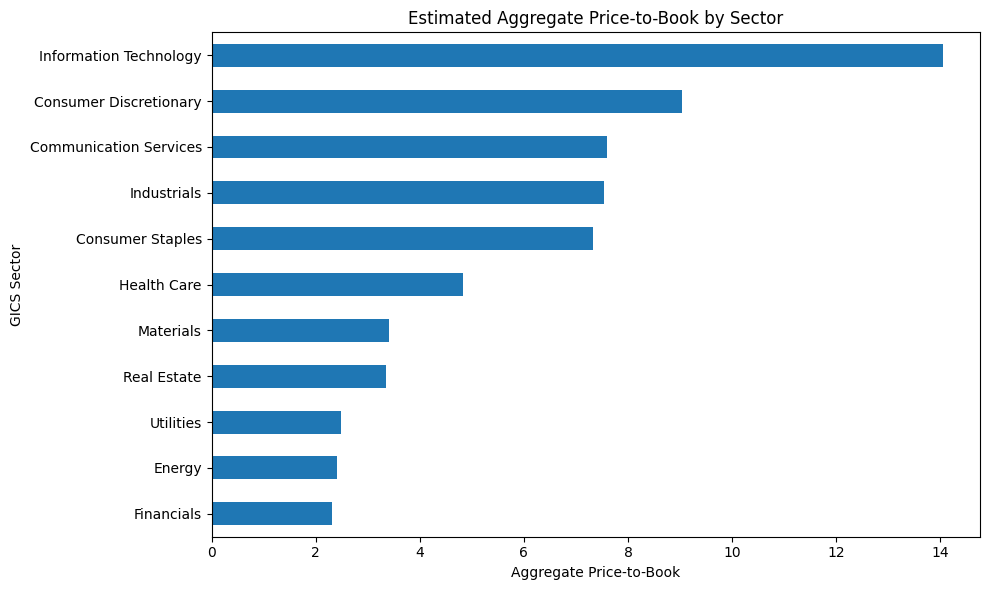

In [132]:
sector_book_value.sort_values("Sector Aggregate P/B").plot(
    kind="barh",
    y="Sector Aggregate P/B",
    figsize=(10, 6),
    legend=False
)

plt.title("Estimated Aggregate Price-to-Book by Sector")
plt.xlabel("Aggregate Price-to-Book")
plt.ylabel("GICS Sector")
plt.tight_layout()
plt.show()

### Note on Negative Book Value in Sector Analysis

In this step, I am not interpreting negative price-to-book values as individual valuation signals. Instead, I am using estimated book value as part of a sector-level total.

A company with negative estimated book value reduces the total estimated book value of its sector. This can affect the sector’s aggregate price-to-book ratio, but it does not automatically make the sector calculation invalid.

The sector aggregate price-to-book ratio is calculated as:

`Total Sector Market Cap / Total Sector Estimated Book Value`

As long as the total estimated book value for the sector remains positive, the aggregate sector ratio can still be interpreted as an estimate of how the sector’s market value compares to its combined book value.

### Observation

The sector aggregate price-to-book analysis shows that valuation differs across sectors.

Financials had one of the lower aggregate price-to-book ratios, which was expected because book value is often more directly connected to financial companies’ balance sheets.

The sector with the highest estimated S&P 500 weight also had the highest aggregate price-to-book ratio. This is important because it means the most influential sector in the index is also trading at a much higher valuation compared to book value.

This suggests that the S&P 500’s overall valuation is strongly affected by its largest and most highly valued sectors.

For this step, I used total sector market capitalization divided by total sector estimated book value. This means the analysis is based on the sector as a whole, not a simple average of individual company ratios.

## Step 28: Compare Sector Weight and Sector Valuation

After calculating sector weights and sector aggregate price-to-book ratios, I compared both metrics side by side.

This helps show whether the sectors with the largest estimated S&P 500 weights are also trading at higher valuations compared to book value.

In [133]:
sector_book_value = (
    sp500_combined
    .groupby("GICS Sector")[["Estimated Book Value"]]
    .sum()
)

In [134]:
sector_weight_valuation = sector_weights.join(sector_book_value)

In [135]:
sector_weight_valuation

,Market Cap,Estimated Weight,Dollars per $100,Estimated Book Value
GICS Sector,,,,
Information Technology,23103487563776,0.321955,32.195517,1.643287e+12
Communication Services,12768397987840,0.177932,17.793209,1.680844e+12
Financials,8098423286784,0.112854,11.285436,3.490884e+12
Consumer Discretionary,7097496271360,0.098906,9.890609,7.859241e+11
Industrials,5626718735360,0.078410,7.841029,7.462657e+11
Health Care,5395836646400,0.075193,7.519287,1.117104e+12
Consumer Staples,3630911598592,0.050598,5.059802,4.952469e+11
Energy,2119789565952,0.029540,2.954001,8.802650e+11
Utilities,1449459286016,0.020199,2.019872,5.833676e+11


In [136]:
sector_weight_valuation["Sector Aggregate P/B"] = (
    sector_weight_valuation["Market Cap"] / sector_weight_valuation["Estimated Book Value"]
)

In [137]:
sector_weight_valuation.sort_values("Dollars per $100", ascending=False)

,Market Cap,Estimated Weight,Dollars per $100,Estimated Book Value,Sector Aggregate P/B
GICS Sector,,,,,
Information Technology,23103487563776,0.321955,32.195517,1.643287e+12,14.059313
Communication Services,12768397987840,0.177932,17.793209,1.680844e+12,7.596420
Financials,8098423286784,0.112854,11.285436,3.490884e+12,2.319878
Consumer Discretionary,7097496271360,0.098906,9.890609,7.859241e+11,9.030765
Industrials,5626718735360,0.078410,7.841029,7.462657e+11,7.539833
Health Care,5395836646400,0.075193,7.519287,1.117104e+12,4.830200
Consumer Staples,3630911598592,0.050598,5.059802,4.952469e+11,7.331518
Energy,2119789565952,0.029540,2.954001,8.802650e+11,2.408127
Utilities,1449459286016,0.020199,2.019872,5.833676e+11,2.484641


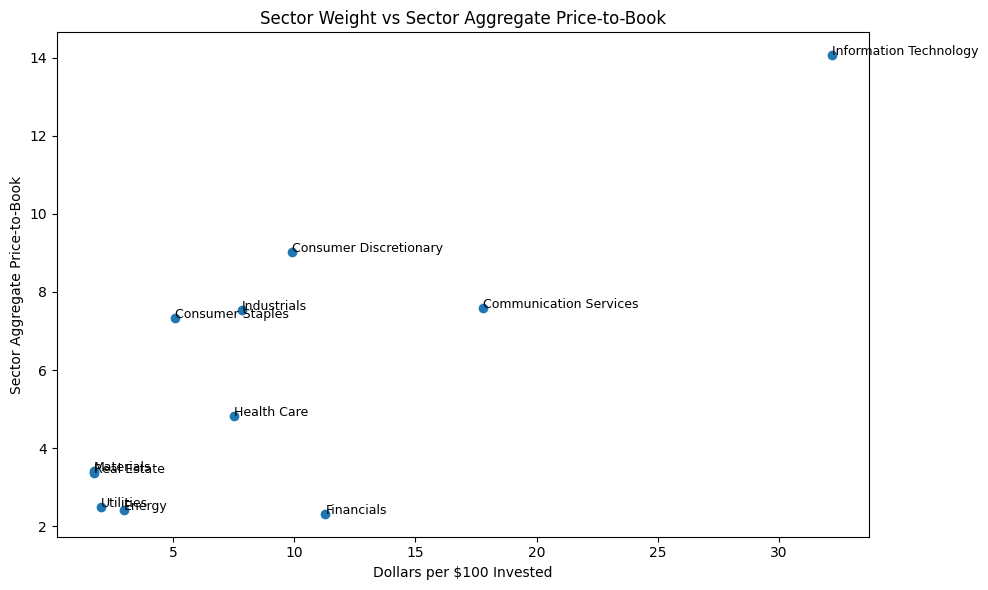

In [138]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sector_weight_valuation["Dollars per $100"],
    sector_weight_valuation["Sector Aggregate P/B"]
)

for sector in sector_weight_valuation.index:
    plt.text(
        sector_weight_valuation.loc[sector, "Dollars per $100"],
        sector_weight_valuation.loc[sector, "Sector Aggregate P/B"],
        sector,
        fontsize=9
    )

plt.title("Sector Weight vs Sector Aggregate Price-to-Book")
plt.xlabel("Dollars per $100 Invested")
plt.ylabel("Sector Aggregate Price-to-Book")
plt.tight_layout()
plt.show()

### Sector Weight vs Valuation Chart

I created a scatter plot to compare sector weight with sector valuation.

Each point represents one GICS sector. The x-axis shows how much of every $100 invested goes into that sector, while the y-axis shows that sector’s aggregate price-to-book ratio.

### Observation

The sector weight vs valuation chart compares how much of every $100 invested goes into each sector with each sector’s aggregate price-to-book ratio.

Sectors farther to the right represent a larger estimated S&P 500 weight, while sectors higher on the chart have higher aggregate price-to-book ratios.

This chart helps connect allocation and valuation. A sector with both a large weight and a high aggregate price-to-book ratio can have a strong influence on the overall valuation of the S&P 500.

The chart also shows that sector weight and valuation are not the same thing. Some sectors have large weights but lower aggregate price-to-book ratios, while others may have smaller weights but higher valuation levels.

## Step 29: Analyze the Most Influential Sector

After comparing sector weight and sector valuation, I looked deeper into the sector with the largest estimated weight and highest aggregate price-to-book ratio.

This helps explain what is driving the sector’s influence in the S&P 500. Instead of only looking at the sector level, I analyzed the companies and sub-industries inside the sector.

In [139]:
top_sector = sp500_combined[sp500_combined["GICS Sector"] == "Information Technology"]
top_sector.head(10)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,Founded year,Company age,YF Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield,Estimated Weight,Dollars per $100,Estimated Book Value
1,Q,Qnity Electronics,Information Technology,Semiconductor Materials & Equipment,"Wilmington, Delaware",2025-11-03,2058873,2025,2025.0,1.0,Q,31331428352,4.413467,45.284850,34.056520,0.22,0.000437,0.043661,7.099051e+09
22,DELL,Dell Technologies,Information Technology,"Technology Hardware, Storage & Peripherals","Round Rock, Texas",2024-09-23,1571996,2016,2016.0,10.0,DELL,153301499904,-62.243927,27.194925,15.998371,1.16,0.002136,0.213631,-2.462915e+09
27,LITE,Lumentum,Information Technology,Communications Equipment,"San Jose, California",2026-03-23,1633978,2015,2015.0,11.0,LITE,66284187648,78.295520,163.730150,51.445610,NaN,0.000924,0.092369,8.465898e+08
28,HPE,Hewlett Packard Enterprise,Information Technology,"Technology Hardware, Storage & Peripherals","Houston, Texas",2015-11-02,1645590,2015,2015.0,11.0,HPE,39832162304,1.610342,NaN,11.041108,1.90,0.000555,0.055508,2.473521e+10
30,KEYS,Keysight Technologies,Information Technology,Electronic Equipment & Instruments,"Santa Rosa, California",2018-11-06,1601046,2014 (1939),2014.0,12.0,KEYS,62588981248,10.086648,64.137960,35.314740,NaN,0.000872,0.087220,6.205132e+09
42,APP,AppLovin,Information Technology,Application Software,"Palo Alto, California",2025-09-22,1751008,2012,2012.0,14.0,APP,156458844160,73.738510,46.343628,21.880680,NaN,0.002180,0.218031,2.121806e+09
45,CRWD,CrowdStrike,Information Technology,Systems Software,"Austin, Texas",2024-06-24,1535527,2011,2011.0,15.0,CRWD,118734512128,26.786245,NaN,75.902560,NaN,0.001655,0.165461,4.432667e+09
49,DDOG,Datadog,Information Technology,Application Software,"New York City, New York",2025-07-09,1561550,2010,2010.0,16.0,DDOG,50711085056,13.457070,459.580660,53.910160,NaN,0.000707,0.070668,3.768360e+09
59,TEL,TE Connectivity,Information Technology,Electronic Manufacturing Services,"Galway, Ireland",2011-10-17,1385157,2007,2007.0,19.0,TEL,62775111680,4.863740,21.967314,17.037302,1.41,0.000875,0.087479,1.290676e+10
61,PANW,Palo Alto Networks,Information Technology,Systems Software,"Santa Clara, California",2023-06-20,1327567,2005,2005.0,21.0,PANW,148733345792,13.726144,101.886116,46.198590,NaN,0.002073,0.207265,1.083577e+10


In [140]:
top_sector.sort_values("Dollars per $100", ascending=False)[
    ["Symbol", "Security", "GICS Sub-Industry", "Market Cap", "Dollars per $100", "Price to Book"]
].head(10)

,Symbol,Security,GICS Sub-Industry,Market Cap,Dollars per $100,Price to Book
140,NVDA,Nvidia,Semiconductors,5000753840128,6.968725,31.790790
230,AAPL,Apple Inc.,"Technology Hardware, Storage & Peripherals",4215711727616,5.874742,47.854282
242,MSFT,Microsoft,Systems Software,3071648202752,4.280449,7.858951
301,AVGO,Broadcom,Semiconductors,1995804770304,2.781224,24.994368
225,MU,Micron Technology,Semiconductors,736658391040,1.026559,10.168905
264,AMD,Advanced Micro Devices,Semiconductors,681185640448,0.949256,10.809831
276,INTC,Intel,Semiconductors,557483884544,0.776873,4.847054
236,ORCL,Oracle Corporation,Application Software,552243953664,0.769571,16.459368
212,LRCX,Lam Research,Semiconductor Materials & Equipment,368343187456,0.513299,36.322605
190,CSCO,Cisco,Communications Equipment,361454731264,0.503700,7.572197


In [141]:
top_sector_subindustry = (
    top_sector
    .groupby("GICS Sub-Industry")[["Market Cap", "Estimated Book Value", "Dollars per $100"]]
    .sum()
)

top_sector_subindustry["Aggregate P/B"] = (
    top_sector_subindustry["Market Cap"] / top_sector_subindustry["Estimated Book Value"]
)

top_sector_subindustry = top_sector_subindustry.sort_values(
    "Dollars per $100",
    ascending=False
)

top_sector_subindustry

,Market Cap,Estimated Book Value,Dollars per $100,Aggregate P/B
GICS Sub-Industry,,,,
Semiconductors,9930303236096,6.039052e+11,13.838225,16.443481
"Technology Hardware, Storage & Peripherals",5010763755520,1.356689e+11,6.982674,36.933778
Systems Software,3508877260800,4.213939e+11,4.889743,8.326835
Application Software,1783165337600,1.888510e+11,2.484903,9.442183
Semiconductor Materials & Equipment,1031743891456,4.720518e+10,1.437771,21.856580
Communications Equipment,776943183872,6.971611e+10,1.082697,11.144386
Electronic Components,392552271872,3.437768e+10,0.547035,11.418811
IT Consulting & Other Services,360461309952,8.312764e+10,0.502315,4.336239
Electronic Equipment & Instruments,139052077056,3.913239e+10,0.193774,3.553375


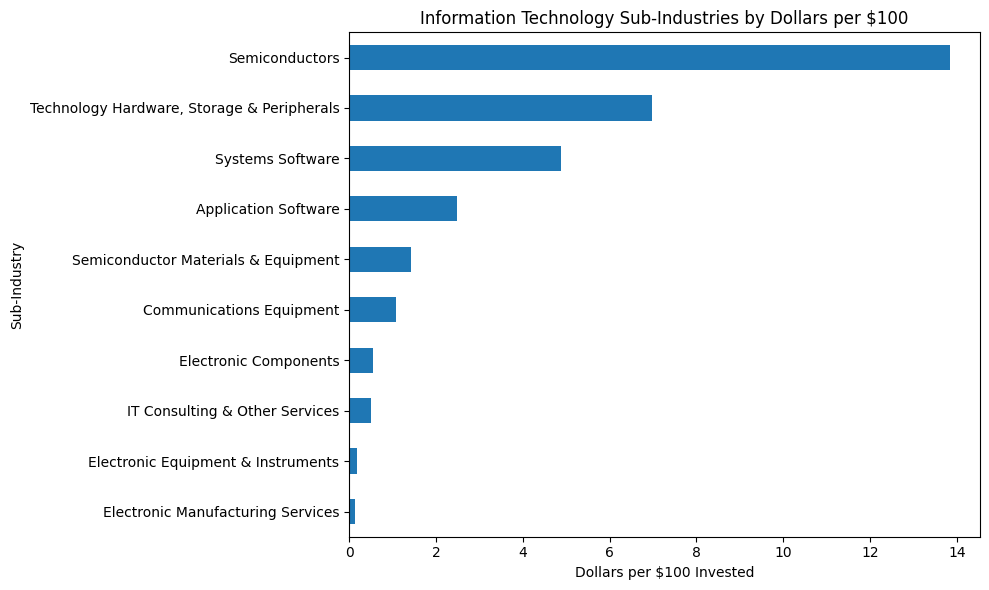

In [142]:
top_sector_subindustry.head(10).sort_values("Dollars per $100").plot(
    kind="barh",
    y="Dollars per $100",
    figsize=(10, 6),
    legend=False
)

plt.title("Information Technology Sub-Industries by Dollars per $100")
plt.xlabel("Dollars per $100 Invested")
plt.ylabel("Sub-Industry")
plt.tight_layout()
plt.show()

### Observation

The deeper Information Technology analysis shows that the sector’s estimated weight is not evenly spread across all of its sub-industries.

Semiconductors make up the large majority of the sector’s estimated weight. This means that the high influence of Information Technology in the S&P 500 is heavily driven by semiconductor companies rather than being equally distributed across all technology sub-industries.

This is important because it shows that even within a large sector, exposure can still be concentrated in a smaller group of businesses. The S&P 500 may appear broadly diversified by sector, but some sectors are strongly influenced by specific sub-industries.

## Step 30: Analyze Sub-Industry Weight Across the S&P 500

After analyzing the most influential sector, I looked at sub-industries across the entire S&P 500.

Earlier, I counted how many companies belonged to each sub-industry. In this step, I use estimated market-cap weight to see which sub-industries receive the largest investment allocation.

This helps show what types of businesses dominate the S&P 500 by estimated investment weight, not just by number of companies.

In [143]:
subindustry_weights = (
    sp500_combined
    .groupby("GICS Sub-Industry")[["Market Cap", "Estimated Weight", "Dollars per $100"]]
    .sum()
    .sort_values("Dollars per $100", ascending=False)
)

subindustry_weights.head(15)

,Market Cap,Estimated Weight,Dollars per $100
GICS Sub-Industry,,,
Interactive Media & Services,11129169248256,0.155089,15.508886
Semiconductors,9930303236096,0.138382,13.838225
"Technology Hardware, Storage & Peripherals",5010763755520,0.069827,6.982674
Systems Software,3508877260800,0.048897,4.889743
Broadline Retail,3028674899968,0.042206,4.220564
Pharmaceuticals,2035932119040,0.028371,2.837143
Diversified Banks,1935749382144,0.026975,2.697534
Application Software,1783165337600,0.024849,2.484903
Automobile Manufacturers,1621566525440,0.022597,2.259710


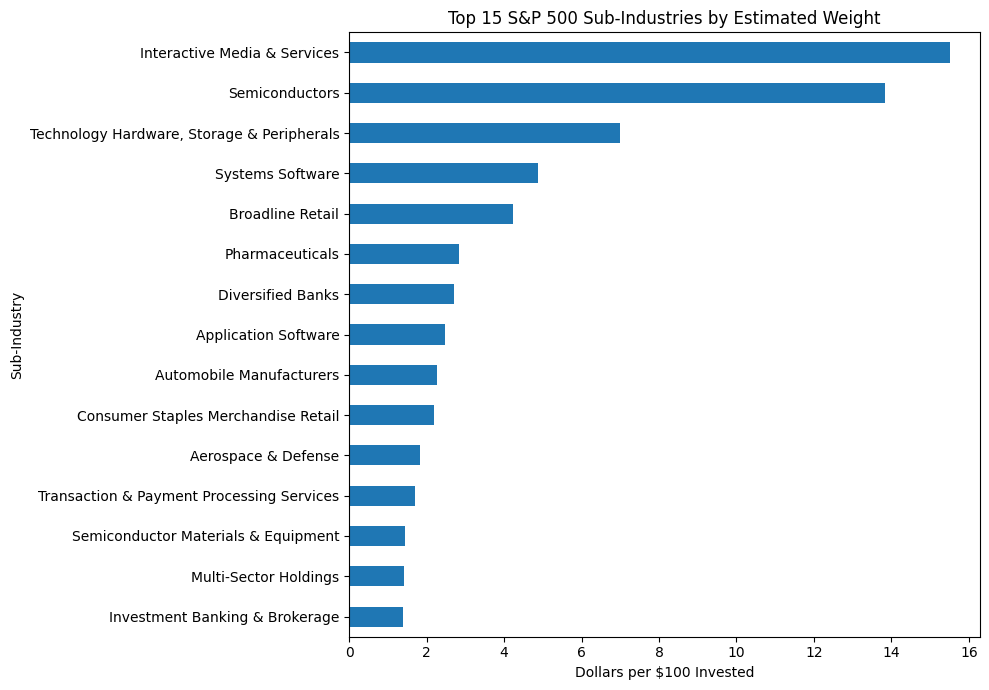

In [144]:
subindustry_weights.head(15).sort_values("Dollars per $100").plot(
    kind="barh",
    y="Dollars per $100",
    figsize=(10, 7),
    legend=False
)

plt.title("Top 15 S&P 500 Sub-Industries by Estimated Weight")
plt.xlabel("Dollars per $100 Invested")
plt.ylabel("Sub-Industry")
plt.tight_layout()
plt.show()

### Observation

The sub-industry weight analysis shows which specific business types dominate the S&P 500 by estimated investment weight.

This is different from the earlier sub-industry count analysis. A sub-industry may not have the most companies, but it can still represent a large part of the index if it contains very large companies.

One important finding is that the largest sub-industry is not necessarily part of the largest sector. Even though Information Technology is the largest sector by estimated weight, one of the largest sub-industries comes from a different sector.

This shows that looking only at broad sectors can hide important details. Sub-industry analysis gives a more specific view of what types of businesses are really driving the S&P 500’s weight.

## Step 31: Analyze the Largest Sub-Industry

After analyzing sub-industries across the S&P 500, I looked deeper into the largest sub-industry by estimated weight.

This helps show which companies are driving that sub-industry and which broader sector it belongs to.

In [145]:
interactive_media = sp500_combined[
    sp500_combined["GICS Sub-Industry"] == "Interactive Media & Services"
].copy()

interactive_media[
    [
        "Symbol",
        "Security",
        "GICS Sector",
        "GICS Sub-Industry",
        "Market Cap",
        "Estimated Weight",
        "Dollars per $100",
        "Price to Book"
    ]
].sort_values("Dollars per $100", ascending=False)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Market Cap,Estimated Weight,Dollars per $100,Price to Book
93,GOOGL,Alphabet Inc. (Class A),Communication Services,Interactive Media & Services,4804742479872,0.066956,6.695577,11.544260
96,GOOG,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,4766215700480,0.066419,6.641888,11.451693
67,META,Meta Platforms,Communication Services,Interactive Media & Services,1558211067904,0.021714,2.171422,7.148847


In [146]:
interactive_media_total_weight = interactive_media["Estimated Weight"].sum()
interactive_media_dollars_per_100 = interactive_media["Dollars per $100"].sum()

print(f"Interactive Media & Services estimated weight: {interactive_media_total_weight:.2%}")
print(f"Interactive Media & Services dollars per $100: ${interactive_media_dollars_per_100:.2f}")

Interactive Media & Services estimated weight: 15.51%
Interactive Media & Services dollars per $100: $15.51


In [147]:
interactive_media_by_company = (
    interactive_media
    .groupby("Security")[["Market Cap", "Estimated Weight", "Dollars per $100"]]
    .sum()
    .sort_values("Dollars per $100", ascending=False)
)

interactive_media_by_company

,Market Cap,Estimated Weight,Dollars per $100
Security,,,
Alphabet Inc. (Class A),4804742479872,0.066956,6.695577
Alphabet Inc. (Class C),4766215700480,0.066419,6.641888
Meta Platforms,1558211067904,0.021714,2.171422


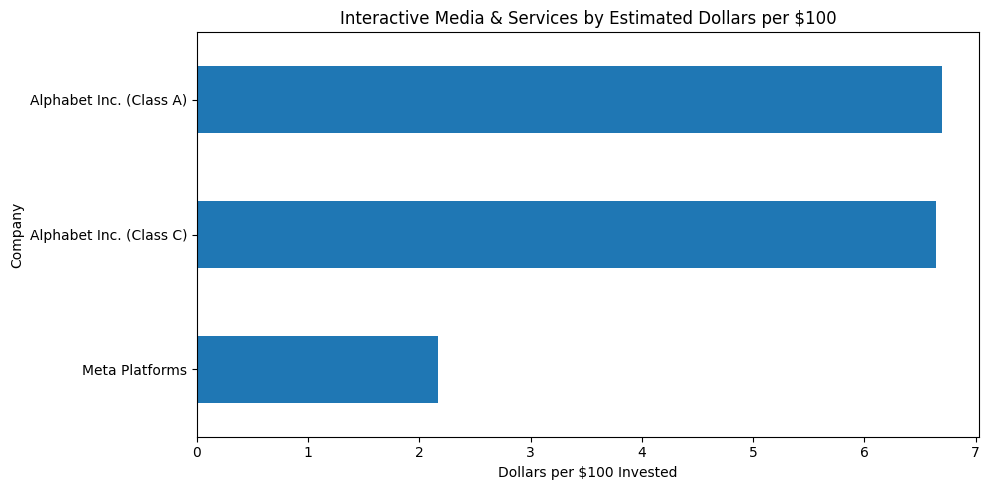

In [148]:
interactive_media_by_company.sort_values("Dollars per $100").plot(
    kind="barh",
    y="Dollars per $100",
    figsize=(10, 5),
    legend=False
)

plt.title("Interactive Media & Services by Estimated Dollars per $100")
plt.xlabel("Dollars per $100 Invested")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

### Classification Note

Interactive Media & Services may feel like it belongs in Information Technology because these companies rely heavily on technology. However, GICS classifies this sub-industry under Communication Services because the main business activity is communication, digital content, search, advertising, social platforms, and interactive media.

This shows that sector labels are based on business classification rules, not just whether a company uses advanced technology.

### Observation

The Interactive Media & Services sub-industry is a major part of the estimated S&P 500 weight.

This is important because it is not part of the largest sector, Information Technology. It belongs to Communication Services, which shows that some of the largest S&P 500 exposures come from outside the biggest sector.

The analysis also shows that this sub-industry is heavily influenced by a small number of very large companies. This means that broad sector labels can hide where the actual investment weight is concentrated.

This reinforces the main idea of the project: buying the S&P 500 gives broad exposure, but the actual investment weight is concentrated in the largest companies, sectors, and sub-industries.

## Step 32: Key Findings So Far

At this point, the project has analyzed the S&P 500 by company count, company age, estimated company weight, sector weight, sub-industry weight, and valuation compared to book value.

### Key Findings

- The S&P 500 is diversified across many companies, but it is not equally weighted.
- If the S&P 500 were split equally across all companies, each company would receive about the same small share. However, the estimated market-cap-weighted version gives much more weight to the largest companies.
- The top 10 companies make up a large part of the estimated index weight.
- The largest companies receive far more of every $100 invested than the average company.
- The company age analysis shows that the S&P 500 includes both older established companies and newer companies. Many companies are not extremely young, but the index is also not made only of very old companies.
- Information Technology is the largest sector by estimated weight.
- Sector exposure looks different when measured by company count versus market-cap weight.
- The estimated aggregate price-to-book ratio shows that the market values the S&P 500 companies much higher than their combined estimated book value.
- Sector valuation differs a lot across the index.
- Financials had one of the lower aggregate price-to-book ratios, which makes sense because book value is often more directly connected to financial companies.
- The largest sub-industry is not necessarily inside the largest sector, showing that broad sector labels can hide important details.

### Interpretation

Buying the S&P 500 gives broad exposure, but the investment is still heavily influenced by the largest companies, largest sectors, and largest sub-industries.

The project shows that market-cap weighting matters. An investor is not buying every company equally. Instead, larger companies and sectors receive much more of every dollar invested.

This changed my understanding of the S&P 500. It is diversified because it includes many companies and sectors, but it is not as evenly diversified as it may first appear. A relatively small number of large companies and major sectors have a strong influence on the index.

The age analysis also adds context. The S&P 500 includes companies with a wide range of ages, which suggests that the index contains both long-established businesses and newer companies that have grown large enough to be included.

## Step 33: Limitations

This project gives a useful estimate of what an investor is buying when buying the S&P 500, but it has some limitations.

### Limitations

- The estimated company weights are based on regular market capitalization from yfinance, not the official float-adjusted S&P 500 weights.
- Financial data from yfinance may have missing, delayed, or unusual values.
- Price-to-book ratios can be affected by accounting rules, intangible assets, share repurchases, and negative book equity.
- The estimated book value calculation depends on the accuracy of the price-to-book data.
- Some companies have multiple share classes, which can create data issues, such as the Berkshire Hathaway BRK-B price-to-book issue found in this project.
- This project analyzes the S&P 500 at one point in time. The index changes as stock prices, market caps, and company memberships change.

### Future Improvements

- Compare the estimated weights to an actual S&P 500 ETF such as VOO, SPY, or IVV.
- Use official holdings data from an ETF provider to check how close the estimates are.
- Add more valuation metrics such as earnings yield, free cash flow yield, or debt ratios.
- Save the collected financial data so the yfinance loop does not need to run every time.
- Create a polished report summarizing the findings for non-technical readers.

## Step 34: Final Conclusion

This project started with the question: What am I actually buying when I buy the S&P 500?

The analysis shows that the S&P 500 gives broad exposure to many companies, sectors, and industries, but it is not equally weighted. A small group of the largest companies makes up a large part of the estimated index weight.

The project also showed that sector exposure changes depending on how it is measured. By company count, some sectors appear very large, but by estimated market-cap weight, the largest sectors receive much more of every dollar invested.

The valuation analysis showed that the market values the S&P 500 companies much higher than their combined estimated book value. The estimated aggregate price-to-book ratio gives a broad view of how the market price compares to accounting book value.

One of the biggest lessons from this project is that the S&P 500 is diversified, but not evenly diversified. Buying the S&P 500 does not mean buying every company or sector equally. Market-cap weighting gives more influence to the largest companies and sectors.

Overall, this project helped me better understand what is inside the S&P 500, how the index is weighted, and how market value compares to book value. It also gave me practice with data collection, data cleaning, financial analysis, pandas, yfinance, matplotlib, Git, GitHub, and explaining data findings clearly.

## Step 35: Notebook Review

Before creating the final report and README, I reviewed the notebook for readability.

I kept important troubleshooting notes and data-quality decisions because they show the analysis process. I only removed or reduced outputs that were visually messy and did not add much explanation, such as long progress printouts from loops.

## Export Final Datasets

After completing the main analysis, I exported the final cleaned and summarized datasets.

This makes the project easier to review and prevents needing to rerun the full yfinance data collection process every time.

In [151]:
from pathlib import Path

Path("data/cleaned").mkdir(parents=True, exist_ok=True)

sp500_combined.to_csv("data/cleaned/sp500_combined_financials.csv", index=False)